# DS3000 Group Project - Group UG-38

## Members
* Jacob Hills
* Anhad Kaur
* John-Anthony Mastrogiacomo
* Seongmin Park

# File Structure
* GroupProject/
    * Code/
        * DS3000_GroupProject.ipynb
        * requirements.txt
    * Geography Hierarchy File_2025_CSV/
        * Documentation/
            * ...
        * Geography_Hierarchy_File_2025.csv
        * Geography_Hierarchy_List_2025.csv
    * HouseholdSpend_2025_CSV/
        * Documentation/
            * ...
        * HouseholdSpend_(HHS)_2025_GEO_P1.csv
        * HouseholdSpend_(HHS)_2025_GEO_P2.csv

# 1. Data Prep

## 1.1 Loading Data

In [ ]:
# Download packages
# Uncomment as needed
!pip install polars
!pip install pandas
!pip install numpy
!pip install distfit
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install scipy
!pip install umap-learn
!pip install xgboost
!pip install shap

In [ ]:
# Import packages
# DataFrames
import polars as pl
import pandas as pd

# Calculations
import numpy as np
from itertools import product
from distfit import distfit

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, silhouette_score
from sklearn.utils import resample
from scipy.stats import pearson3, norm, zscore
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import xgboost as xgb
import shap

# UMAP
import umap.umap_ as umap

# Misc
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Define Path to data
HHS_PATH = '/content/drive/MyDrive/Colab Notebooks/Final Project/HouseholdSpend_2025_CSV_fixed'
GHS_PATH = '/content/drive/MyDrive/Colab Notebooks/Final Project/Geographic Hierarchy File_2025_CSV-Geographic Hierarchy File_2025_CSV'

In [ ]:
# Read HHS csv files
spend1 = pl.scan_csv(f'{HHS_PATH}/HouseholdSpend_(HHS)_2025_GEO_P1.csv').drop('CODE')
spend2 = pl.scan_csv(f'{HHS_PATH}/HouseholdSpend_(HHS)_2025_GEO_P2.csv').drop('CODE')

In [ ]:
# Read GHS csv files
geoFile = pl.scan_csv(f'{GHS_PATH}/Geography_Hierarchy_File_2025.csv')
geoList = pl.scan_csv(f'{GHS_PATH}/Geography_Hierarchy_List_2025.csv')

## 1.(a) Data Filtration
The raw CSVs contain several geographic levels in the GEO column (`province`, `CMA`, `CSD`, `PRCDDA`, etc.).

Filter your data to focus on `PRCDDA` (Dissemination Area).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!'find' '/content/drive/MyDrive' -maxdepth 5

/content/drive/MyDrive
/content/drive/MyDrive/jacobhills_act_resume.pdf
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/Colab Notebooks/Another copy of Assignment_1_Clean.ipynb
/content/drive/MyDrive/Colab Notebooks/251286610_H01.ipynb
/content/drive/MyDrive/Colab Notebooks/insurance_churn_analysis.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/251286610_H10.ipynb
/content/drive/MyDrive/Colab Notebooks/Final Project
/content/drive/MyDrive/Colab Notebooks/Final Project/Documentation
/content/drive/MyDrive/Colab Notebooks/Final Project/Documentation/DemoStats 2024 - Variables Change List.csv
/content/drive/MyDrive/Colab Notebooks/Final Project/Documentation/DemoStats 2024 - Variables List.csv
/content/drive/MyDrive/Colab Notebooks/Final Project/Documentation/DemoStats 2024 - Metadata.csv
/content/drive/MyDrive/Colab Notebooks/Final Project/Documentation/DemoStats 2024 - Technical Document.pdf
/content/drive/MyDrive/Colab 

In [ ]:
spend1.head().collect()

GEO,HSBASHHD,HSHNIAGG,HSAGDISPIN,HSAGDISCIN,HSTT001,HSTE001,HSTX001,HSTC001,HSFD001S,HSHO001S,HSHF001S,HSTR001S,HSHC001S,HSPC001S,HSRE001S,HSRO001S,HSTA018S,HSGC001S,HSME001S,HSSH001S,HSCL030S,HSED002S,HSEP011S,HSMG001S,HSTE001ZBS,HSWH040S,HSWH041S,HSWH042S,HSWH050S,HSWH028S,HSFD001,HSFD003,HSFD990,HSFD991,HSFD992,HSFD993,…,HSRE116,HSRE076,HSRE050,HSRE051M,HSRE052,HSRE060,HSRE061,HSRE067,HSRE062,HSRE063,HSRE064,HSRE065,HSRE066,HSRE091,HSRE146,HSRE073,HSRE074,HSRE142,HSRV001,HSRV020,HSRV003,HSRV003A,HSRV003B,HSRV004,HSRV007,HSRV005,HSRV005B,HSRV005M1,HSRV005M2,HSRV010,HSRV011,HSRV012,HSRV016,HSRV081,HSRV013,HSRV021,HSRV022
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""CAN""",16288077,2.0943e12,1.6234e12,1.0510e12,2.2719e12,1.9016e12,3.9998e11,1.3611e12,2.0409e11,1.0180e11,5.7393e10,2.0479e11,5.2266e10,3.1549e10,8.8535e10,3.7627e9,7.3218e10,2.2752e10,2.9280e10,4.1678e11,4.6327e10,2.8613e10,1.1568e11,2.4791e10,3.7027e11,2.7802e11,1.6681e10,1.6060e10,5.6934e10,2.5722e9,2.0409e11,1.4677e11,5.6700e10,5.2211e10,3.1411e10,1.6969e10,…,2.2329e9,5.0724e8,3.0680e8,2.0044e8,6.3293e8,4.3651e10,1.4990e10,9.4853e9,1.0867e9,3.3808e9,1.3283e9,2.0525e9,1.0373e9,8.1495e9,6.6594e9,1.4900e9,1.8643e10,1.8682e9,1.5365e10,1.0936e10,2.1616e9,1.5096e9,6.5203e8,7.7892e8,1.9912e9,6.0043e9,2.6154e9,2.0255e9,1.3634e9,4.4286e9,9.9365e8,3.7183e8,5.5965e8,2.5034e9,2.4767e8,8.8614e8,1.3696e9
"""CMACA""",24133,3.3437e9,2.7727e9,1.9055e9,3.1049e9,2.7563e9,4.8433e8,2.0278e9,3.1522e8,1.6762e8,8.4753e7,3.2837e8,7.5784e7,5.1884e7,1.3578e8,4.0445e6,1.5873e8,1.1406e7,4.2057e7,5.5567e8,6.4414e7,3.2098e7,2.0769e8,3.6458e7,3.4855e8,2.4918e8,1.3628e7,1.0467e7,7.2294e7,2.9769e6,3.1522e8,2.3165e8,8.3123e7,7.6084e7,4.4006e7,2.5648e7,…,3.1159e6,654962.46538,397267.128376,257695.337004,790920.895628,6.5492e7,2.2418e7,1.6337e7,1.3691e6,3.6689e6,1.3432e6,2.3257e6,1.0427e6,1.2805e7,1.0849e7,1.9560e6,2.6235e7,4.0335e6,2.8200e7,2.0729e7,5.4977e6,3.4210e6,2.0768e6,884267.024414,3.3278e6,1.1019e7,4.5383e6,3.2674e6,3.2133e6,7.4717e6,990309.907664,1.1160e6,651319.067761,4.7141e6,166025.750127,2.1616e6,2.3864e6
"""CMACA""",98080,1.2340e10,9.3428e9,6.2238e9,1.1927e10,1.1055e10,2.5789e9,7.6258e9,1.2662e9,6.0487e8,3.1750e8,1.1128e9,2.9187e8,1.9500e8,4.8307e8,1.8384e7,5.9037e8,1.3483e8,1.7879e8,2.0087e9,2.9208e8,1.3134e8,7.4039e8,1.0937e8,8.7288e8,5.4949e8,-3.0957e7,4.4480e7,2.7389e8,3.5972e7,1.2662e9,9.4584e8,3.1705e8,2.8751e8,1.7961e8,8.8498e7,…,1.1905e7,3.0449e6,1.8181e6,1.2268e6,2.4495e6,2.2934e8,1.0402e8,7.5240e7,5.5377e6,1.7673e7,7.0011e6,1.0672e7,5.5699e6,3.5064e7,2.9736e7,5.3275e6,8.4182e7,6.0764e6,1.0007e8,7.7421e7,2.9234e7,1.1534e7,1.7700e7,9.5077e6,6.3284e6,3.2351e7,1.4514e7,1.1176e7,6.6605e6,2.2651e7,5.6093e6,1.2354e6,1.2742e6,1.4532e7,460121.583796,6.4197e6,7.6523e6
"""CMACA""",6403,6.5841e8,5.1922e8,3.4446e8,6.5737e8,6.1767e8,1.1742e8,4.5699e8,7.7328e7,3.8950e7,2.0582e7,7.6139e7,1.7926e7,1.1788e7,2.7969e7,874125.039207,3.6189e7,1.0865e7,9.1599e6,1.0745e8,1.6001e7,5.7745e6,3.7470e7,5.7818e6,3.9698e7,2.3267e7,-1.0478e6,1.6995e6,1.4255e7,1.5253e6,7.7328e7,5.8979e7,1.8267e7,1.6442e7,1.0194e7,5.1246e6,…,550698.03738,87068.637589,55075.730658,31992.906931,121821.117125,1.2588e7,6.8462e6,5.3371e6,276563.578988,939644.836647,373261.722811,566383.113836,292840.493294,1.7697e6,1.4869e6,282766.685995,3.5426e6,429804.782283,7.3068e6,5.6044e6,2.3059e6,920256.663165,1.3857e6,867622.588355,256137.24263,2.1748e6,957864.678765,700591.424197,516303.139007,1.7023e6,544381.057326,117482.66573,73760.20447,966716.36149,16158.590581,445705.991668,504851.779241
"""CMACA""",6155,7.1158e8,5.4439e8,3.6379e8,7.0099e8,6.5165e8,1.4321e8,4.5941e8,7.7016e7,3.7453e7,2.0303e7,7.2691e7,1.7990e7,1.1632e7,2.9597e7,1.0695e6,3.6115e7,9.3005e6,9.7173e6,1.1181e8,1.711

In [ ]:
spend2.head().collect()

GEO,HSRO001,HSRO002,HSRO003,HSRO005,HSRO004,HSRO010,HSTA018,HSTA005,HSTA006,HSTA007,HSTA009,HSTA010,HSTA008,HSTA002,HSTA020,HSTA015,HSTA016,HSGC001,HSGC002,HSGC003,HSGC010,HSGC003A,HSGC003B,HSGC003C,HSME001,HSME040,HSME036,HSME012,HSME045,HSME014,HSME037,HSME016,HSME017,HSME024,HSME021,HSME019,…,HSMG003,HSMG004,HSMG010,HSMG009,HSTE001ZB,HSWH040,HSWH021,HSWH022,HSWH041,HSWH026,HSWH027,HSWH042,HSWH031,HSWH032,HSWH050,HSOI030Z,HSOI030,HSWH028,HSWH050B,HSWH003A,HSWH003B,HSWH005,HSWH006,HSWH007,HSWH008,HSWH009M,HSWH010A,HSWH010B,HSWH011,HSWH012,HSWH013,HSWH014,HSWH015,HSWH016,HSWH017,HSWH100,HSWH101
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""CAN""",3.7627e9,4.3881e8,4.8526e8,4.7009e8,1.8852e9,4.8335e8,7.3218e10,4.2079e10,1.5540e10,2.6471e10,9.3065e9,1.7165e10,6.7492e7,2.1914e10,2.0958e10,9.5537e8,9.2253e9,2.2752e10,1.6045e10,6.7066e9,3.6763e9,2.3888e9,1.2875e9,3.0303e9,2.9280e10,1.6797e10,7.8461e8,2.8096e9,5.6465e9,9.8228e8,3.2941e9,9.4518e8,1.9218e9,1.6773e7,2.5567e8,1.3435e8,…,6.7367e9,3.2341e9,2.7546e9,1.2066e10,3.7027e11,2.7802e11,4.4971e11,-1.7169e11,1.6681e10,4.4485e10,-2.7804e10,1.6060e10,2.6028e10,-9.9678e9,5.6934e10,2.3637e10,3.3297e10,2.5722e9,5.6934e10,4.6491e9,2.9077e9,4.3505e8,6.3815e9,5.8297e9,6.2802e8,1.8536e9,4.8629e9,3.4977e8,3.0696e9,1.7813e9,4.7886e8,3.4226e9,1.7395e8,8.2310e7,4.1266e8,1.5578e10,4.0367e9
"""CMACA""",4.0445e6,385018.833927,291581.62119,309909.303813,2.5722e6,485773.398625,1.5873e8,5.8879e7,2.4831e7,3.4036e7,1.3237e7,2.0799e7,12563.151093,7.9082e7,7.6754e7,2.3287e6,2.0773e7,1.1406e7,7.8804e6,3.5257e6,2.4282e6,1.5778e6,850399.688225,1.0976e6,4.2057e7,2.5149e7,1.2919e6,4.4959e6,9.7604e6,955811.324034,4.1673e6,1.5521e6,2.3651e6,25921.097516,294767.630385,227797.707285,…,7.4658e6,4.6212e6,5.4507e6,1.8920e7,3.4855e8,2.4918e8,3.5145e8,-1.0226e8,1.3628e7,1.9705e7,-6.0770e6,1.0467e7,1.6165e7,-5.6977e6,7.2294e7,3.0136e7,4.2158e7,2.9769e6,7.2294e7,1.3510e7,2.5327e6,1.3628e6,7.3621e6,5.1764e6,359085.654434,2.1675e6,6.2472e6,212785.099283,1.3957e6,1.6327e6,647977.86001,3.1190e6,307527.543497,112931.462252,582101.277121,2.0062e7,5.5040e6
"""CMACA""",1.8384e7,2.6495e6,1.2522e6,2.0244e6,1.1302e7,1.1557e6,5.9037e8,3.7036e8,1.2473e8,2.4337e8,9.4584e7,1.4878e8,2.2713e6,1.6548e8,1.6124e8,4.2452e6,5.4522e7,1.3483e8,1.0864e8,2.6193e7,1.1803e7,7.6691e6,4.1336e6,1.4390e7,1.7879e8,1.2444e8,2.7854e6,1.4168e7,4.7993e7,4.7263e6,2.8822e7,4.8234e6,1.2251e7,26079.409589,7.2940e6,1.3243e6,…,3.6997e7,8.5291e6,1.0658e7,5.3190e7,8.7288e8,5.4949e8,1.2796e9,-7.3013e8,-3.0957e7,8.2709e7,-1.1367e8,4.4480e7,6.1493e7,-1.7013e7,2.7389e8,1.2573e8,1.4816e8,3.5972e7,2.7389e8,3.1512e7,2.1039e7,1.7417e6,3.5949e7,1.7422e7,1.7346e6,1.6234e7,1.5659e7,1.4233e6,1.2251e7,6.8414e6,1.5717e6,7.4840e6,724764.86546,49277.76939,349050.46145,7.8906e7,2.2997e7
"""CMACA""",874125.039207,129968.035728,57667.114749,89546.581486,543439.485728,53503.821517,3.6189e7,1.8318e7,5.4285e6,1.2806e7,4.8339e6,7.9719e6,83894.106414,1.4374e7,1.4018e7,356363.140802,3.4967e6,1.0865e7,8.7283e6,2.1365e6,1.0034e6,651989.613511,351413.575688,1.1331e6,9.1599e6,6.0321e6,132206.728671,683281.776319,2.2809e6,207633.289254,1.6094e6,221591.619632,581218.433205,933.954698,239407.816986,58310.854193,…,2.0576e6,300677.488565,659189.895989,2.7643e6,3.9698e7,2.3267e7,5.1206e7,-2.7940e7,-1.0478e6,3.6195e6,-4.6672e6,1.6995e6,2.2286e6,-529118.865233,1.4255e7,7.3074e6,6.9472e6,1.5253e6,1.4255e7,1.8590e6,1.3789e6,79940.118528,1.4095e6,1.5231e6,153925.433997,1.1843e6,1.1156e6,212506.711991,641286.95465,311834.81557,99565.863962,486070.726333,24439.943344,2252.928934,100903.92491,3.0151e6,656340.602829
"""CMACA""",1.0695e6,148531.75453,68749.791001,108926.690125,674371.001267,68899.498403,3.6115e7,2.0563e7,6.5126e6,1.3910e7,5.3340e6,8.5762e6,1

In [ ]:
# Filter GEO column to only have PRCDDA
# spend1
spend1 = spend1.filter(pl.col('GEO') == 'PRCDDA')
spend1.head().collect()

GEO,HSBASHHD,HSHNIAGG,HSAGDISPIN,HSAGDISCIN,HSTT001,HSTE001,HSTX001,HSTC001,HSFD001S,HSHO001S,HSHF001S,HSTR001S,HSHC001S,HSPC001S,HSRE001S,HSRO001S,HSTA018S,HSGC001S,HSME001S,HSSH001S,HSCL030S,HSED002S,HSEP011S,HSMG001S,HSTE001ZBS,HSWH040S,HSWH041S,HSWH042S,HSWH050S,HSWH028S,HSFD001,HSFD003,HSFD990,HSFD991,HSFD992,HSFD993,…,HSRE116,HSRE076,HSRE050,HSRE051M,HSRE052,HSRE060,HSRE061,HSRE067,HSRE062,HSRE063,HSRE064,HSRE065,HSRE066,HSRE091,HSRE146,HSRE073,HSRE074,HSRE142,HSRV001,HSRV020,HSRV003,HSRV003A,HSRV003B,HSRV004,HSRV007,HSRV005,HSRV005B,HSRV005M1,HSRV005M2,HSRV010,HSRV011,HSRV012,HSRV016,HSRV081,HSRV013,HSRV021,HSRV022
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""PRCDDA""",227,2.6823e7,2.0393e7,1.3607e7,2.6448e7,2.4335e7,5.4431e6,1.6920e7,2.8802e6,1.3292e6,711659.516933,2.3899e6,668630.235525,448684.510062,1.1229e6,45068.095948,1.3539e6,286903.223949,521569.264355,4.1619e6,682510.148428,316776.330095,1.7466e6,225817.930939,2.1129e6,1.3293e6,38816.692833,153936.025409,508384.183685,82488.418384,2.8802e6,2.1452e6,726140.816749,659787.446427,414699.524849,201448.491303,…,27321.562209,5949.970576,3489.383877,2460.586699,5600.974686,552123.61542,272465.360189,201737.223794,13270.8546,43156.839745,17099.001088,26057.838657,14300.44205,101582.318301,87930.716968,13651.601333,168952.226948,9123.709982,208259.913122,161646.395867,67019.02732,28102.841628,38916.185692,8653.063542,15356.875843,70617.429161,32957.150594,27410.09404,10250.184526,46613.517256,9174.44121,2039.353414,2984.234962,32415.487669,1546.667326,14104.011398,16764.808945
"""PRCDDA""",148,2.0631e7,1.5006e7,1.0447e7,1.8951e7,1.8333e7,5.0019e6,1.2031e7,1.9633e6,917801.114063,462765.977777,1.6211e6,492538.611137,293616.580828,744282.628052,38154.948342,1.1123e6,234750.931935,596078.812838,2.9059e6,468390.839918,179796.878952,1.0916e6,208919.647015,617422.77719,321345.848273,-126878.961955,61061.166886,316468.673457,45426.050528,1.9633e6,1.4837e6,474285.486279,432047.282283,264205.521941,138324.96039,…,17157.96837,3130.117245,1923.278811,1206.838434,4006.163698,385542.89647,197302.382771,153442.152389,8110.554765,27175.134555,10686.792506,16488.342049,8574.541063,64000.152074,55608.651418,8391.500655,119094.746643,5145.614982,138431.708971,102990.794619,36564.42254,15903.751311,20660.671228,6125.542897,10425.790334,49875.038848,20033.402642,21056.738794,8784.897412,35440.914352,7576.279108,1471.635922,3013.847946,23379.151376,1012.972958,10037.311127,12328.867291
"""PRCDDA""",217,2.4982e7,1.9145e7,1.2877e7,2.3245e7,2.2511e7,5.0357e6,1.5746e7,2.7642e6,1.2585e6,630450.46807,2.1013e6,760045.201358,413603.393883,997953.012331,60993.430883,1.2591e6,357350.018738,517663.710192,3.8005e6,598695.039498,226121.093801,1.4443e6,284418.80816,734479.491209,310988.106613,-150342.179678,75381.907699,432367.518781,66084.137795,2.7642e6,2.1137e6,641921.340789,586159.817413,353019.558401,192933.468231,…,21978.543283,3967.393466,2618.598459,1348.795006,5392.884721,532376.584622,294660.193203,233852.640822,10761.919101,38560.539158,15559.316154,23001.223004,11485.094122,78482.944105,66556.735922,11926.208183,152562.509861,6670.937452,173926.392534,129689.056678,45683.395359,18356.014225,27327.381134,7986.809587,13750.734896,62268.116835,28831.655523,21384.890533,12051.57078,44237.335856,9466.826441,1871.720556,3844.326126,29054.462733,1190.08065,12437.225968,15427.156115
"""PRCDDA""",256,2.9207e7,2.2279e7,1.4973e7,2.7666e7,2.6518e7,5.9072e6,1.8527e7,3.1922e6,1.4568e6,743198.496523,2.5697e6,844515.876136,483194.397362,1.1689e6,62657.604077,1.5144e6,390936.799146,638356.259886,4.4527e6,709557.837645,299983.444792,1.7747e6,309317.801601,1.1479e6,560185.511791,-145281.203037,144361.347131,508494.901103,80127.809122,3.1922e6,2.4164e6,767773.603

In [ ]:
# spend2
spend2 = spend2.filter(pl.col('GEO') == 'PRCDDA')
spend2.head().collect()

GEO,HSRO001,HSRO002,HSRO003,HSRO005,HSRO004,HSRO010,HSTA018,HSTA005,HSTA006,HSTA007,HSTA009,HSTA010,HSTA008,HSTA002,HSTA020,HSTA015,HSTA016,HSGC001,HSGC002,HSGC003,HSGC010,HSGC003A,HSGC003B,HSGC003C,HSME001,HSME040,HSME036,HSME012,HSME045,HSME014,HSME037,HSME016,HSME017,HSME024,HSME021,HSME019,…,HSMG003,HSMG004,HSMG010,HSMG009,HSTE001ZB,HSWH040,HSWH021,HSWH022,HSWH041,HSWH026,HSWH027,HSWH042,HSWH031,HSWH032,HSWH050,HSOI030Z,HSOI030,HSWH028,HSWH050B,HSWH003A,HSWH003B,HSWH005,HSWH006,HSWH007,HSWH008,HSWH009M,HSWH010A,HSWH010B,HSWH011,HSWH012,HSWH013,HSWH014,HSWH015,HSWH016,HSWH017,HSWH100,HSWH101
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""PRCDDA""",45068.095948,4264.032903,2234.10459,3594.42193,31739.554862,3235.981662,1.3539e6,839051.698319,274424.027702,557762.949663,219933.223565,337829.726098,6864.720954,370430.35501,360563.65493,9866.700079,144385.743033,286903.223949,231413.181788,55490.042161,25800.640581,16764.696247,9035.944333,29689.40158,521569.264355,421474.577788,8838.381122,50851.991088,153835.105651,16698.398592,83184.695034,17183.453181,43558.348927,114.04875,38294.225769,7617.216543,…,79571.405066,16659.585211,23470.599485,106116.341177,2.1129e6,1.3293e6,3.2569e6,-1.9276e6,38816.692833,165788.414332,-126971.721499,153936.025409,169788.016478,-15851.991069,508384.183685,242366.693782,266017.489904,82488.418384,508384.183685,25105.747398,41207.204995,2335.525944,43899.229604,19124.610143,2095.481356,29812.734566,35146.428985,3479.180115,18667.241236,8236.95199,834.473353,12356.120672,1214.515913,81.880915,238.14635,213747.508213,50801.201938
"""PRCDDA""",38154.948342,4932.231569,2167.312667,3267.481817,25402.903496,2385.018795,1.1123e6,758971.01823,244224.059464,511307.057553,175335.498097,335971.559456,3439.901214,265217.304073,258776.974684,6440.329389,88095.798819,234750.931935,188681.393206,46069.538729,21767.657345,14144.151277,7623.506069,24301.881384,596078.812838,499856.717519,9788.338189,62438.147025,91188.060911,12698.689683,226310.860253,11994.18125,33749.401271,461.244968,38053.925888,9908.008893,…,71863.329347,16451.326413,17161.940999,103443.050256,617422.77719,321345.848273,1.4802e6,-1.1589e6,-126878.961955,104048.09518,-230927.057134,61061.166886,84182.672236,-23121.50535,316468.673457,148239.554577,168229.11888,45426.050528,316468.673457,15388.452113,19913.379204,1555.730346,24595.570858,13321.161264,1449.554237,20693.250749,27751.97038,1979.753185,14281.913289,6054.851206,638.862836,8644.147287,768.621744,38.105455,150.123809,132661.648853,26581.576643
"""PRCDDA""",60993.430883,9484.865596,3851.616974,5942.428098,38070.242216,3644.277997,1.2591e6,811239.989448,261528.36176,542625.135023,191051.644843,351573.49018,7086.492665,347283.490779,339283.673719,7999.81706,100614.854992,357350.018738,286967.281979,70382.736759,30781.778661,20001.331657,10780.447005,39600.958098,517663.710192,390038.371532,6470.992029,38659.711588,104761.250528,18477.856999,142221.017601,10516.606408,40655.769467,74.03761,20778.089526,6419.250492,…,103279.197833,21327.666246,19266.368079,140545.576002,734479.491209,310988.106613,1.9996e6,-1.6886e6,-150342.179678,202060.346482,-352402.52616,75381.907699,115345.27213,-39963.364431,432367.518781,188817.703859,243549.814922,66084.137795,432367.518781,30360.532063,28592.191459,2177.313076,30853.875281,18315.295724,2005.843349,23340.659969,32739.417988,2233.579158,18566.327805,8963.749438,833.120469,11595.247516,1041.401309,55.752517,274.405589,192554.971851,27863.834218
"""PRCDDA""",62657.604077,8290.478385,3677.462676,5552.656767,41084.081513,4052.924736,1.5144e6,975104.804446,310985.125564,655875.97582,240168.197083,415707.778737,8243.703061,407274.505832,397350.822495,9923.683337,132057.254196,390936.799146,313471.244166,7

In [ ]:
# Concat into one dataset (diagonally)
# spend = [[spend1, null],
#          [null, spend2]]
spend = pl.concat([spend1, spend2], how='diagonal')

In [ ]:
spend.head().collect()

GEO,HSBASHHD,HSHNIAGG,HSAGDISPIN,HSAGDISCIN,HSTT001,HSTE001,HSTX001,HSTC001,HSFD001S,HSHO001S,HSHF001S,HSTR001S,HSHC001S,HSPC001S,HSRE001S,HSRO001S,HSTA018S,HSGC001S,HSME001S,HSSH001S,HSCL030S,HSED002S,HSEP011S,HSMG001S,HSTE001ZBS,HSWH040S,HSWH041S,HSWH042S,HSWH050S,HSWH028S,HSFD001,HSFD003,HSFD990,HSFD991,HSFD992,HSFD993,…,HSMG003,HSMG004,HSMG010,HSMG009,HSTE001ZB,HSWH040,HSWH021,HSWH022,HSWH041,HSWH026,HSWH027,HSWH042,HSWH031,HSWH032,HSWH050,HSOI030Z,HSOI030,HSWH028,HSWH050B,HSWH003A,HSWH003B,HSWH005,HSWH006,HSWH007,HSWH008,HSWH009M,HSWH010A,HSWH010B,HSWH011,HSWH012,HSWH013,HSWH014,HSWH015,HSWH016,HSWH017,HSWH100,HSWH101
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""PRCDDA""",227,2.6823e7,2.0393e7,1.3607e7,2.6448e7,2.4335e7,5.4431e6,1.6920e7,2.8802e6,1.3292e6,711659.516933,2.3899e6,668630.235525,448684.510062,1.1229e6,45068.095948,1.3539e6,286903.223949,521569.264355,4.1619e6,682510.148428,316776.330095,1.7466e6,225817.930939,2.1129e6,1.3293e6,38816.692833,153936.025409,508384.183685,82488.418384,2.8802e6,2.1452e6,726140.816749,659787.446427,414699.524849,201448.491303,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""PRCDDA""",148,2.0631e7,1.5006e7,1.0447e7,1.8951e7,1.8333e7,5.0019e6,1.2031e7,1.9633e6,917801.114063,462765.977777,1.6211e6,492538.611137,293616.580828,744282.628052,38154.948342,1.1123e6,234750.931935,596078.812838,2.9059e6,468390.839918,179796.878952,1.0916e6,208919.647015,617422.77719,321345.848273,-126878.961955,61061.166886,316468.673457,45426.050528,1.9633e6,1.4837e6,474285.486279,432047.282283,264205.521941,138324.96039,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""PRCDDA""",217,2.4982e7,1.9145e7,1.2877e7,2.3245e7,2.2511e7,5.0357e6,1.5746e7,2.7642e6,1.2585e6,630450.46807,2.1013e6,760045.201358,413603.393883,997953.012331,60993.430883,1.2591e6,357350.018738,517663.710192,3.8005e6,598695.039498,226121.093801,1.4443e6,284418.80816,734479.491209,310988.106613,-150342.179678,75381.907699,432367.518781,66084.137795,2.7642e6,2.1137e6,641921.340789,586159.817413,353019.558401,192933.468231,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""PRCDDA""",256,2.9207e7,2.2279e7,1.4973e7,2.7666e7,2.6518e7,5.9072e6,1.8527e7,3.1922e6,1.4568e6,743198.496523,2.5697e6,844515.876136,483194.397362,1.1689e6,62657.604077,1.5144e6,390936.799146,638356.259886,4.4527e6,709557.837645,299983.444792,1.7747e6,309317.801601,1.1479e6,560185.511791,-145281.203037,144361.347131,508494.901103,80127.809122,3.1922e6,2.4164e6,767773.603982,699165.815367,428535.045772,222510.691152,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""PRCDDA""",132,1.4251e7,1.1095e7,7.2568e6,1.4012e7,1.3112e7,2.6223e6,9.4083e6,1.6555e6,735373.88144,379035.22333,1.3256e6,417936.024354,254789.356044,604288.088644,27130.858043,712337.050573,159268.399212,280363.6786,2.3106e6,372779.92615,173337.832219,950651.595109,130963.275953,899797.528141,576795.810235,-37559.45182,80871.971968,250810.454989,28878.74277,1.6555e6,1.2445e6,405483.216771,367949.638431,230110.159997,113861.525021,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


## 1.(b): Target Variable Construction
Define the target variable, Housing Burden Ratio (HBR) per `PRCDDA`, as
$$
y = \frac{HSSH001S}{HSAGDISPIN}
$$

Since $y$ is derived from shelter expenditure and disposable income, you must remove all variables mathematically related to either.

Using shelter sub-items to predict a shelter-based ratio is circular.

To avoid leakage, remove all variables starting with HSSH (e.g. `HSSH001`, `HSSH001S`, `HSSH022`, `HSSH034B`, etc.)
and remove the aggregates: `HSAGDISPIN`, `HSAGDISCIN`, `HSHNIAGG`, `HSTT001`, `HSTE001`, `HSTX001`, `HSTC001`.

Note: If you reduce features using any method that involves $y$, do so on the training set only.

In [ ]:
# Define Target variable (HBR)
spend = spend.with_columns(
    (pl.col('HSSH001S') / pl.col('HSAGDISPIN')).alias('HBR')
)

In [ ]:
# Drop all columns starting with HSSH and aggregates
leakage_cols = [c for c in spend.columns if c.startswith("HSSH")]
agg_cols = [
    "HSAGDISPIN", "HSAGDISCIN", "HSHNIAGG",
    "HSTT001", "HSTE001", "HSTX001", "HSTC001"
]
agg_cols_existing = [c for c in agg_cols if c in spend.columns]

spend = spend.drop(leakage_cols + agg_cols_existing)

In [ ]:
spend.head().collect()

GEO,HSBASHHD,HSFD001S,HSHO001S,HSHF001S,HSTR001S,HSHC001S,HSPC001S,HSRE001S,HSRO001S,HSTA018S,HSGC001S,HSME001S,HSCL030S,HSED002S,HSEP011S,HSMG001S,HSTE001ZBS,HSWH040S,HSWH041S,HSWH042S,HSWH050S,HSWH028S,HSFD001,HSFD003,HSFD990,HSFD991,HSFD992,HSFD993,HSFD994,HSFD995,HSFD1100,HSHO001,HSHO010,HSHO011,HSHO013,HSHO012,…,HSMG004,HSMG010,HSMG009,HSTE001ZB,HSWH040,HSWH021,HSWH022,HSWH041,HSWH026,HSWH027,HSWH042,HSWH031,HSWH032,HSWH050,HSOI030Z,HSOI030,HSWH028,HSWH050B,HSWH003A,HSWH003B,HSWH005,HSWH006,HSWH007,HSWH008,HSWH009M,HSWH010A,HSWH010B,HSWH011,HSWH012,HSWH013,HSWH014,HSWH015,HSWH016,HSWH017,HSWH100,HSWH101,HBR
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""PRCDDA""",227,2.8802e6,1.3292e6,711659.516933,2.3899e6,668630.235525,448684.510062,1.1229e6,45068.095948,1.3539e6,286903.223949,521569.264355,682510.148428,316776.330095,1.7466e6,225817.930939,2.1129e6,1.3293e6,38816.692833,153936.025409,508384.183685,82488.418384,2.8802e6,2.1452e6,726140.816749,659787.446427,414699.524849,201448.491303,43639.430274,66353.370323,8947.864599,1.3292e6,63574.668374,30352.868132,3280.466171,29941.334071,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.204083
"""PRCDDA""",148,1.9633e6,917801.114063,462765.977777,1.6211e6,492538.611137,293616.580828,744282.628052,38154.948342,1.1123e6,234750.931935,596078.812838,468390.839918,179796.878952,1.0916e6,208919.647015,617422.77719,321345.848273,-126878.961955,61061.166886,316468.673457,45426.050528,1.9633e6,1.4837e6,474285.486279,432047.282283,264205.521941,138324.96039,29516.799952,42238.203996,5312.667722,917801.114063,42874.582492,20505.305171,2264.852693,20104.424628,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.193655
"""PRCDDA""",217,2.7642e6,1.2585e6,630450.46807,2.1013e6,760045.201358,413603.393883,997953.012331,60993.430883,1.2591e6,357350.018738,517663.710192,598695.039498,226121.093801,1.4443e6,284418.80816,734479.491209,310988.106613,-150342.179678,75381.907699,432367.518781,66084.137795,2.7642e6,2.1137e6,641921.340789,586159.817413,353019.558401,192933.468231,40206.790781,55761.523376,8598.523503,1.2585e6,59647.895515,28353.797428,3199.50498,28094.593106,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.198507
"""PRCDDA""",256,3.1922e6,1.4568e6,743198.496523,2.5697e6,844515.876136,483194.397362,1.1689e6,62657.604077,1.5144e6,390936.799146,638356.259886,709557.837645,299983.444792,1.7747e6,309317.801601,1.1479e6,560185.511791,-145281.203037,144361.347131,508494.901103,80127.809122,3.1922e6,2.4164e6,767773.603982,699165.815367,428535.045772,222510.691152,48120.078444,68607.788615,7957.604688,1.4568e6,69892.184405,33248.607069,3757.195003,32886.382332,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.199864
"""PRCDDA""",132,1.6555e6,735373.88144,379035.22333,1.3256e6,417936.024354,254789.356044,604288.088644,27130.858043,712337.050573,159268.399212,280363.6786,372779.92615,173337.832219,950651.595109,130963.275953,899797.528141,576795.810235,-37559.45182,80871.971968,250810.454989,28878.74277,1.6555e6,1.2445e6,405483.216771,367949.638431,230110.159997,113861.525021,23977.953413,37533.57834,5511.799444,735373.88144,34998.694748,16708.899625,1809.349018,16480.446105,…,null,null,null,null,null,null,null,null,null,n

## 1.(c): Tableau Construction
Construct the variables that can be predictive for the above target.

Diagnostic of what are the main points that determine a `PRCDDA` household expenditure.

In [ ]:
# Use variables with cateogory of Household Expenditures (Category Summary) with Hierarchy level of 4
# See HouseholdSpend 2025 - Metadata.csv

# Consumptions
consumption = [
    'HSFD001S', # Food expenditures
    'HSHO001S', # Household operations
    'HSHF001S', # Household furnishings and equipment
    'HSTR001S', # Transportation
    'HSHC001S', # Health care
    'HSPC001S', # Personal care
    'HSRE001S', # Recreation
    'HSRO001S', # Reading materials and other printed matter
    'HSTA018S', # Tobacco products, alcoholic beverages and cannabis for non-medical use
    'HSGC001S', # Games of chance
    'HSME001S', # Miscellaneous expenditures
    'HSCL030S', # Clothing and accessories
    'HSED002S'  # Education
]

In [ ]:
# Create copy of spend
tableau = spend.select([pl.all()])

In [ ]:
# Total consumption
existing_consumption = [c for c in consumption if c in spend.columns]

# Create total consumption
tableau = tableau.with_columns(
    pl.sum_horizontal([pl.col(c) for c in existing_consumption]).alias("total_consumption")
)

In [ ]:
# Budget shares
for c in existing_consumption:
    tableau = tableau.with_columns(
        (pl.col(c) / pl.col("total_consumption")).alias(f"{c}_share")
    )

In [ ]:
# Function to make sure columns exist before summing
def safe_sum(cols):
    existing = [c for c in cols if c in tableau.columns]
    return pl.sum_horizontal([pl.col(c) for c in existing])


# Necessity vs. Discretionary
tableau = tableau.with_columns([
    (safe_sum(['HSFD001S', 'HSHO001S', 'HSTR001S']) / pl.col('total_consumption')).alias('necessity_share'),
    (safe_sum(['HSRE001S', 'HSCL030S', 'HSED002S']) / pl.col('total_consumption')).alias('discretionary_share')
])

In [ ]:
tableau.head().collect()

GEO,HSBASHHD,HSFD001S,HSHO001S,HSHF001S,HSTR001S,HSHC001S,HSPC001S,HSRE001S,HSRO001S,HSTA018S,HSGC001S,HSME001S,HSCL030S,HSED002S,HSEP011S,HSMG001S,HSTE001ZBS,HSWH040S,HSWH041S,HSWH042S,HSWH050S,HSWH028S,HSFD001,HSFD003,HSFD990,HSFD991,HSFD992,HSFD993,HSFD994,HSFD995,HSFD1100,HSHO001,HSHO010,HSHO011,HSHO013,HSHO012,…,HSWH028,HSWH050B,HSWH003A,HSWH003B,HSWH005,HSWH006,HSWH007,HSWH008,HSWH009M,HSWH010A,HSWH010B,HSWH011,HSWH012,HSWH013,HSWH014,HSWH015,HSWH016,HSWH017,HSWH100,HSWH101,HBR,total_consumption,HSFD001S_share,HSHO001S_share,HSHF001S_share,HSTR001S_share,HSHC001S_share,HSPC001S_share,HSRE001S_share,HSRO001S_share,HSTA018S_share,HSGC001S_share,HSME001S_share,HSCL030S_share,HSED002S_share,necessity_share,discretionary_share
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""PRCDDA""",227,2.8802e6,1.3292e6,711659.516933,2.3899e6,668630.235525,448684.510062,1.1229e6,45068.095948,1.3539e6,286903.223949,521569.264355,682510.148428,316776.330095,1.7466e6,225817.930939,2.1129e6,1.3293e6,38816.692833,153936.025409,508384.183685,82488.418384,2.8802e6,2.1452e6,726140.816749,659787.446427,414699.524849,201448.491303,43639.430274,66353.370323,8947.864599,1.3292e6,63574.668374,30352.868132,3280.466171,29941.334071,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.204083,1.2758e7,0.225763,0.104186,0.055782,0.187326,0.052409,0.035169,0.088013,0.003533,0.106121,0.022488,0.040882,0.053497,0.02483,0.517275,0.16634
"""PRCDDA""",148,1.9633e6,917801.114063,462765.977777,1.6211e6,492538.611137,293616.580828,744282.628052,38154.948342,1.1123e6,234750.931935,596078.812838,468390.839918,179796.878952,1.0916e6,208919.647015,617422.77719,321345.848273,-126878.961955,61061.166886,316468.673457,45426.050528,1.9633e6,1.4837e6,474285.486279,432047.282283,264205.521941,138324.96039,29516.799952,42238.203996,5312.667722,917801.114063,42874.582492,20505.305171,2264.852693,20104.424628,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.193655,9.1249e6,0.215159,0.100582,0.050715,0.177661,0.053977,0.032178,0.081566,0.004181,0.121896,0.025726,0.065324,0.051331,0.019704,0.493401,0.152601
"""PRCDDA""",217,2.7642e6,1.2585e6,630450.46807,2.1013e6,760045.201358,413603.393883,997953.012331,60993.430883,1.2591e6,357350.018738,517663.710192,598695.039498,226121.093801,1.4443e6,284418.80816,734479.491209,310988.106613,-150342.179678,75381.907699,432367.518781,66084.137795,2.7642e6,2.1137e6,641921.340789,586159.817413,353019.558401,192933.468231,40206.790781,55761.523376,8598.523503,1.2585e6,59647.895515,28353.797428,3199.50498,28094.593106,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.198507,1.1946e7,0.23139,0.105347,0.052775,0.1759,0.063624,0.034623,0.083539,0.005106,0.105403,0.029914,0.043334,0.050117,0.018929,0.512637,0.152585
"""PRCDDA""",256,3.1922e6,1.4568e6,743198.496523,2.5697e6,844515.876136,483194.397362,1.1689e6,62657.604077,1.5144e6,390936.799146,638356.259886,709557.837645,299983.444792,1.7747e6,309317.801601,1.1479e6,560185.511791,-145281.203037,144361.347131,508494.901103,80127.809122,3.1922e6,2.4164e6,767773.603982,699165.815367,428535.045772,222510.691152,48120.078444,68607.788615,7957.604688,1.4568e6,69892.184405,33248.607069,3757.195003,32886.382332,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.199864,1.4075e7,0.226805,0.10351,0.052805,0.18258,0.060003,0.034331,0.083053,0.004452,0.107601,0.027776,0.045356,0.050414,0.021314,0.512895,0.154781
"""PRCDDA""",132,1.6555e6,735373.88144,379035.22333,1.3256e6,417936.024354,254789.356044,604288.088644,27130.858043,712337.050573,159268.399212,280

Each `_share` columns represents the share of total consumption spent on a specific category.

We can predict that households that spend a higher share on necessities (vs. discretionary) items may have lower income or different priorities.

# 2. Unsupervised Learning

## a)
### i) Load and merge dataset

Done in Part 1.

### ii) Remove non-numeric columns, zero-variance columns, and handle missing values. Justify.

In [ ]:
# Remove non-numeric columns (GEO, CODE)
# CODE column was removed in Part 1 since it was giving errors that cannot be resolved without removing it.
tableau = tableau.drop('GEO')

In [ ]:
print(len(tableau.columns)) # Length
print(tableau.columns) # Columns

407
['HSBASHHD', 'HSFD001S', 'HSHO001S', 'HSHF001S', 'HSTR001S', 'HSHC001S', 'HSPC001S', 'HSRE001S', 'HSRO001S', 'HSTA018S', 'HSGC001S', 'HSME001S', 'HSCL030S', 'HSED002S', 'HSEP011S', 'HSMG001S', 'HSTE001ZBS', 'HSWH040S', 'HSWH041S', 'HSWH042S', 'HSWH050S', 'HSWH028S', 'HSFD001', 'HSFD003', 'HSFD990', 'HSFD991', 'HSFD992', 'HSFD993', 'HSFD994', 'HSFD995', 'HSFD1100', 'HSHO001', 'HSHO010', 'HSHO011', 'HSHO013', 'HSHO012', 'HSHO014', 'HSHO015', 'HSHO016', 'HSHO017', 'HSHO018', 'HSHO021', 'HSHO019', 'HSHO020', 'HSHO022', 'HSCS030', 'HSCS003', 'HSCS004', 'HSCS005', 'HSCS021', 'HSCS007', 'HSCS008', 'HSCS020', 'HSHO002', 'HSHO003', 'HSHO052', 'HSHO050', 'HSHO006', 'HSCC001', 'HSCC021', 'HSCC022', 'HSHF001', 'HSHF002', 'HSHF003', 'HSHF004', 'HSHF005A', 'HSHF006', 'HSHF008', 'HSHF007', 'HSHF008B', 'HSHF008C', 'HSHF008A', 'HSHE001', 'HSHE002', 'HSHE008', 'HSHE050', 'HSHE051', 'HSHE052', 'HSHE009', 'HSHE009A', 'HSHE009B', 'HSHE009C', 'HSHE009D', 'HSHE010', 'HSHE011', 'HSHE031', 'HSHE011B', 'HSH

In [ ]:
# Materialize tableau
tableau = tableau.collect()

# Remove rows where target is null / infinite
tableau = tableau.filter(
    pl.col("HBR").is_not_null() &
    pl.col("HBR").is_finite()
)

# Predictor columns only
predictor_cols = [c for c in tableau.columns if c != "HBR"]

# Convert NaN -> null so Polars can fill them
tableau = tableau.with_columns([
    pl.when(pl.col(c).is_nan())
    .then(None)
    .otherwise(pl.col(c))
    .alias(c)
    for c in predictor_cols
])

# Fill nulls in predictors with median
tableau = tableau.with_columns([
    pl.col(c).fill_null(pl.col(c).median()).alias(c)
    for c in predictor_cols
])

# Remove zero-variance columns
variance_df = tableau.select([
    pl.col(c).var().alias(c) for c in predictor_cols
])

zero_var_cols = [
    c for c in variance_df.columns
    if variance_df[c][0] == 0 or variance_df[c][0] is None
]

tableau = tableau.drop(zero_var_cols)

print("Zero-variance columns removed:", zero_var_cols)
print("Final tableau shape:", tableau.shape)

Zero-variance columns removed: ['HSRO001', 'HSRO002', 'HSRO003', 'HSRO005', 'HSRO004', 'HSRO010', 'HSTA018', 'HSTA005', 'HSTA006', 'HSTA007', 'HSTA009', 'HSTA010', 'HSTA008', 'HSTA002', 'HSTA020', 'HSTA015', 'HSTA016', 'HSGC001', 'HSGC002', 'HSGC003', 'HSGC010', 'HSGC003A', 'HSGC003B', 'HSGC003C', 'HSME001', 'HSME040', 'HSME036', 'HSME012', 'HSME045', 'HSME014', 'HSME037', 'HSME016', 'HSME017', 'HSME024', 'HSME021', 'HSME019', 'HSME020', 'HSME039', 'HSME030', 'HSME038', 'HSME006', 'HSOI040Z', 'HSOI040', 'HSRM002A', 'HSRM002B', 'HSRM003A', 'HSRM003B', 'HSRM004', 'HSRM005', 'HSRM006', 'HSRM007', 'HSRM008M', 'HSRM009A', 'HSRM009B', 'HSRM010', 'HSRM011', 'HSRM012', 'HSRM013', 'HSRM015M', 'HSRM016', 'HSCL030', 'HSCL029', 'HSCL027', 'HSCL028', 'HSCL026', 'HSCL024', 'HSCL025', 'HSCL023', 'HSCL021', 'HSCL022', 'HSCL020', 'HSCL019', 'HSCL018', 'HSCL017', 'HSCL016', 'HSCL014', 'HSCL015', 'HSED002', 'HSED003', 'HSED004', 'HSED005', 'HSED006', 'HSED007', 'HSED008', 'HSED030', 'HSED025', 'HSED024',

In [ ]:
# Show null counts
tableau.null_count()

HSBASHHD,HSFD001S,HSHO001S,HSHF001S,HSTR001S,HSHC001S,HSPC001S,HSRE001S,HSRO001S,HSTA018S,HSGC001S,HSME001S,HSCL030S,HSED002S,HSEP011S,HSMG001S,HSTE001ZBS,HSWH040S,HSWH041S,HSWH042S,HSWH050S,HSWH028S,HSFD001,HSFD003,HSFD990,HSFD991,HSFD992,HSFD993,HSFD994,HSFD995,HSFD1100,HSHO001,HSHO010,HSHO011,HSHO013,HSHO012,HSHO014,…,HSRE142,HSRV001,HSRV020,HSRV003,HSRV003A,HSRV003B,HSRV004,HSRV007,HSRV005,HSRV005B,HSRV005M1,HSRV005M2,HSRV010,HSRV011,HSRV012,HSRV016,HSRV081,HSRV013,HSRV021,HSRV022,HBR,total_consumption,HSFD001S_share,HSHO001S_share,HSHF001S_share,HSTR001S_share,HSHC001S_share,HSPC001S_share,HSRE001S_share,HSRO001S_share,HSTA018S_share,HSGC001S_share,HSME001S_share,HSCL030S_share,HSED002S_share,necessity_share,discretionary_share
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


I replaced null values with median because it does not assume the normality and symmetry of data. Since we don't know the distribution of data yet, median is appropriate.

Also, it is robust to outliers.

Here, I removed rows with NaN values in `HBR` column (response variable).

This is because to prevent situation where when defining the response, `HSAGDISPIN` could've been 0, which will lead to NaN due to divide by 0 error.

### iv) Split data

In [ ]:
# Define features and target
X = tableau.drop('HBR')
y = tableau['HBR']

print(f"Number of remaining features:", len(X.columns))

Number of remaining features: 274


In [ ]:
# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42 # For reproducibility
)

80/20 split is used because:
* 80% of data for training should be sufficient to learn patterns, and
* 20% of data for testing should be reliable for evaluations

### v) Distribution of y

In [ ]:
y_train.describe()

statistic,value
str,f64
"""count""",45485.0
"""null_count""",0.0
"""mean""",0.257026
"""std""",0.058526
"""min""",0.11686
"""25%""",0.222215
"""50%""",0.251285
"""75%""",0.283068
"""max""",4.494179


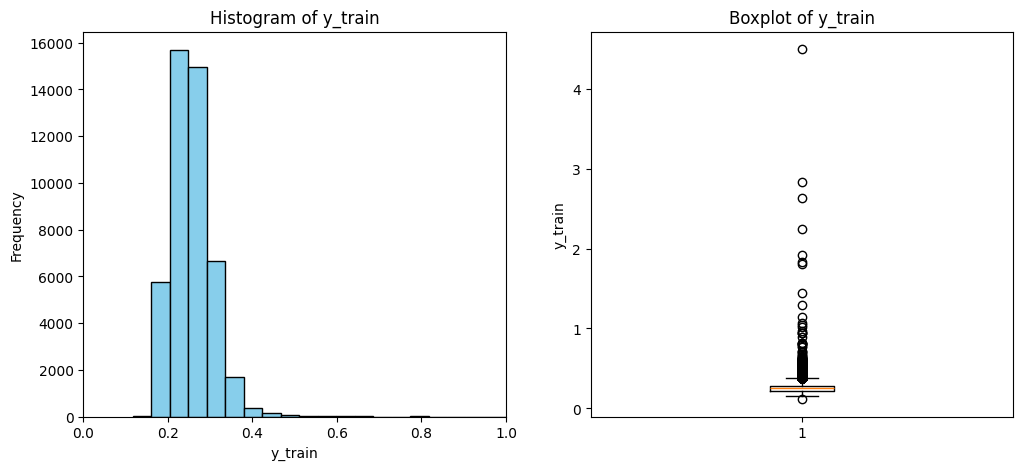

In [ ]:
# Configure 1x2 plots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
ax[0].hist(y_train, bins=100, color='skyblue', edgecolor='black')
ax[0].set_title('Histogram of y_train')
ax[0].set_xlabel('y_train')
ax[0].set_ylabel('Frequency')
ax[0].set_xlim(0, 1)

# Boxplot
ax[1].boxplot(y_train)
ax[1].set_title('Boxplot of y_train')
ax[1].set_ylabel('y_train')

plt.show()

We can see that the $y$ is skewed to the right.

### vi) Identify and visualise the top predictors correlated with y

(e.g. bar chart of absolute correlations)

Provide at least one additional visualisation that
reveals an interesting pattern in the data and discuss your results.

In [ ]:
# Convert pl.DataFrame to numpy
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()

In [ ]:
# Calculate correlations
corrs = np.corrcoef(X_train_np.T, y_train_np)[-1, :-1]
abs_corrs = np.abs(corrs)

In [ ]:
top10_idx = np.argsort(abs_corrs)[::-1][:10] # Indices of top 10 predictors

# Get Top 10 predictors and values
top10_feat = [X_train.columns[i] for i in top10_idx]
top10_val = abs_corrs[top10_idx]

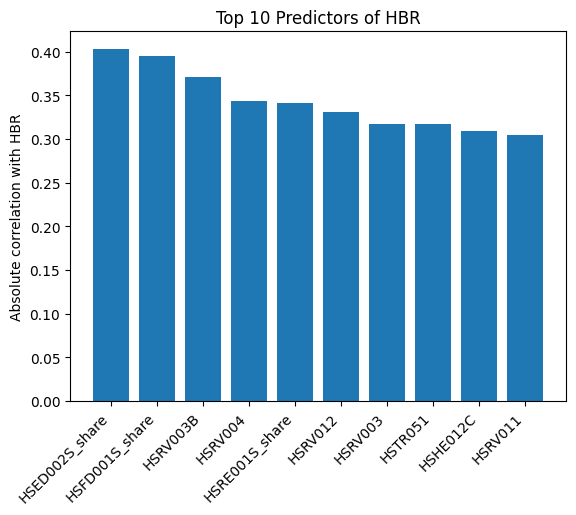

In [ ]:
# Bar chart
plt.bar(top10_feat, top10_val)
plt.title('Top 10 Predictors of HBR')
plt.xticks(rotation=45, ha='right') # For readability
plt.ylabel('Absolute correlation with HBR')

plt.show()

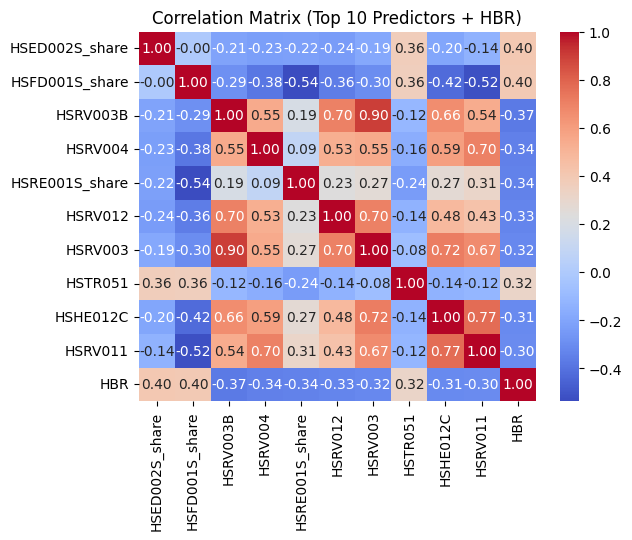

In [ ]:
# Additional Visual: Heatmap of Top 10 Predictors
# To examine how they correlate with each other and HBR
heatmap_feat = top10_feat + ['HBR']

# Convert data to np.array
data_np = np.column_stack([X_train[col].to_numpy() for col in top10_feat] + [y_train.to_numpy()])

# Compute confusion matrix
corr_matrix = np.corrcoef(data_np, rowvar=False)

# Plot Heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f', # Round to 2 decimal places
    cmap='coolwarm',
    xticklabels=heatmap_feat,
    yticklabels=heatmap_feat
)
plt.title('Correlation Matrix (Top 10 Predictors + HBR)')

plt.show()

## 2.(b): K-Means Clustering

Before clustering we standardise the features (excluding HBR) so that no single variable dominates by scale.
All sklearn estimators are fit on the training set only and then applied to the test set where applicable.

In [ ]:
# Standardise features (fit on train, transform both splits)
scaler = StandardScaler()
X_test_np  = X_test.to_numpy()

X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled  = scaler.transform(X_test_np)

print('Training set shape:', X_train_scaled.shape)
print('Test set shape    :', X_test_scaled.shape)

Training set shape: (45485, 274)
Test set shape    : (11372, 274)


### i) Run KMeans for k = 2, …, 12

In [ ]:
k_values   = range(2, 13)
inertias   = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_scaled)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_scaled, labels, sample_size = 5000, random_state=42))
    print(f'k={k:2d}  inertia={km.inertia_:,.0f}  silhouette={sil_scores[-1]:.4f}')

k= 2  inertia=7,897,574  silhouette=0.7863
k= 3  inertia=5,899,987  silhouette=0.5775
k= 4  inertia=5,023,012  silhouette=0.4080
k= 5  inertia=4,522,599  silhouette=0.3051
k= 6  inertia=4,187,918  silhouette=0.2225
k= 7  inertia=3,985,201  silhouette=0.1452
k= 8  inertia=3,819,470  silhouette=0.1366
k= 9  inertia=3,707,078  silhouette=0.1333
k=10  inertia=3,603,773  silhouette=0.1220
k=11  inertia=3,511,902  silhouette=0.1134
k=12  inertia=3,422,333  silhouette=0.1192


### ii) Elbow curve and Silhouette scores

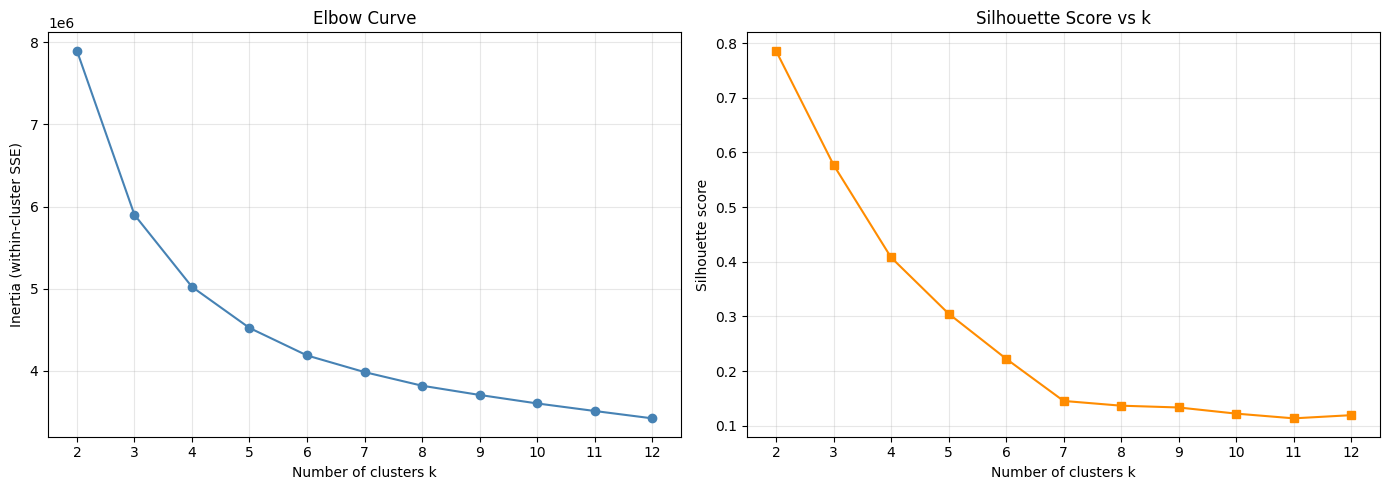

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(list(k_values), inertias, marker='o', color='steelblue')
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow Curve')
axes[0].set_xticks(list(k_values))
axes[0].grid(alpha=0.3)

# Silhouette scores
axes[1].plot(list(k_values), sil_scores, marker='s', color='darkorange')
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xticks(list(k_values))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### iii) Selecting the optimal k

Both the elbow curve and silhouette score agree on k=2 as the optimal number of clusters.
The silhouette score peaked at k=2 (0.7863) and declined monotonically for all higher values,
indicating that 2 clusters produce the most well-separated and compact groupings.
The elbow curve showed its steepest inertia drop between k=2 and k=3, after which
gains diminished substantially.

Both methods agree, which gives strong confidence in k=2.
Our standardisation choices (z-score scaling, median imputation for sparse columns)
tend to compress the feature space uniformly, which can smooth out fine-grained
cluster structure and push the apparent optimum toward smaller k.
A log-transformation or PCA pre-processing would likely shift the optimal k.

In [ ]:
optimal_k = int(k_values[int(np.argmax(sil_scores))])
print(f'Silhouette-optimal k : {optimal_k}')
print(f'Silhouette score     : {max(sil_scores):.4f}')

# Re-fit final model on train set
km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
train_labels = km_final.fit_predict(X_train_scaled)
test_labels  = km_final.predict(X_test_scaled)

Silhouette-optimal k : 2
Silhouette score     : 0.7863


### iv) Cluster sizes and feature interpretation

We compare cluster means on a handful of interpretable variables to assign descriptive names.

In [ ]:
# Attach cluster labels to a pandas DataFrame for easy groupby
X_train_pd = X_train.to_pandas()
X_train_pd['cluster'] = train_labels

# Cluster sizes
sizes = X_train_pd['cluster'].value_counts().sort_index()
print('Cluster sizes:')
print(sizes.to_string())

# Interpretable variables commonly in the HHS dataset
interp_vars = [c for c in [
    'HSBASHHD',   # number of households (proxy for area size)
    'HSFD001S',   # food expenditure share
    'HSTR001S',   # transportation share
    'HSHC001S',   # health care share
    'HSED002S',   # education share
] if c in X_train_pd.columns]

cluster_means = X_train_pd.groupby('cluster')[interp_vars].mean()
print('\nCluster means (raw scale):')
print(cluster_means.round(2).to_string())

Cluster sizes:
cluster
0     1166
1    44319

Cluster means (raw scale):
         HSBASHHD     HSFD001S     HSTR001S    HSHC001S    HSED002S
cluster                                                            
0         1265.14  17658443.95  18017112.33  4368738.13  3516968.53
1          260.04   3214752.80   3219187.36   827512.65   425331.56


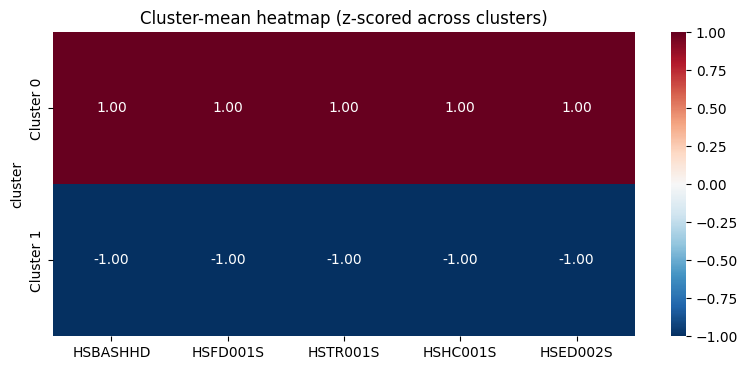

Cluster names:
  0: High-Volume Urban Areas
  1: Typical Households


In [67]:
# Visualise cluster means as a heatmap (z-scored for comparability)
cm_z = cluster_means.apply(zscore, axis=0)

fig, ax = plt.subplots(figsize=(max(8, len(interp_vars)*1.4), 3 + optimal_k*0.4))
sns.heatmap(cm_z, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=interp_vars, yticklabels=[f'Cluster {i}' for i in range(optimal_k)],
            ax=ax)
ax.set_title('Cluster-mean heatmap (z-scored across clusters)')
plt.tight_layout()
plt.show()

# Assign descriptive names based on the dominant pattern
cluster_names = {0: 'High-Volume Urban Areas', 1: 'Typical Households'}
print('Cluster names:')
for k_id, name in cluster_names.items():
    print(f'  {k_id}: {name}')

### v) Boxplot of target variable HBR by cluster

We examine whether the K-Means clusters, identified purely from expenditure features, also capture meaningful differences in the Housing Burden Ratio (HBR).

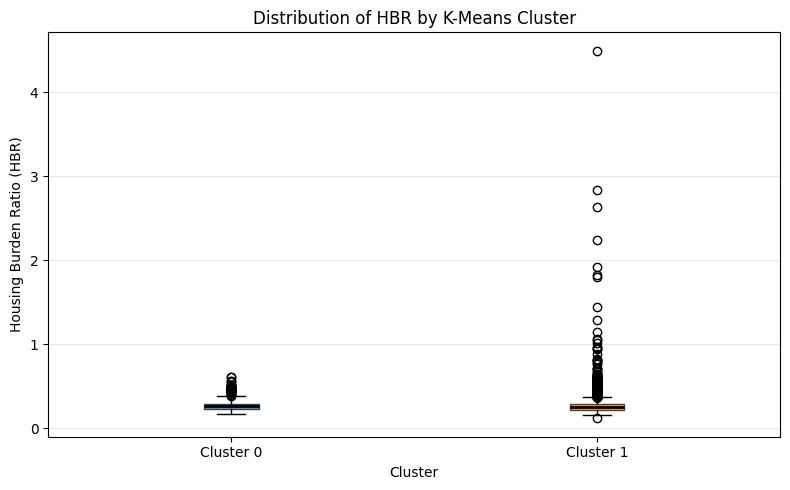

Cluster 0: median=0.2590  IQR=0.0603  n=1166
Cluster 1: median=0.2511  IQR=0.0609  n=44319


In [ ]:
y_train_np_arr = y_train.to_numpy()

fig, ax = plt.subplots(figsize=(8, 5))
data_by_cluster = [y_train_np_arr[train_labels == k_id] for k_id in range(optimal_k)]
bp = ax.boxplot(data_by_cluster,
                labels=[f'Cluster {k_id}' for k_id in range(optimal_k)],
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2))

colors = plt.cm.tab10.colors[:optimal_k]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Cluster')
ax.set_ylabel('Housing Burden Ratio (HBR)')
ax.set_title('Distribution of HBR by K-Means Cluster')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary stats
for k_id in range(optimal_k):
    vals = y_train_np_arr[train_labels == k_id]
    print(f'Cluster {k_id}: median={np.median(vals):.4f}  IQR={np.percentile(vals,75)-np.percentile(vals,25):.4f}  n={len(vals)}')

## 2.(c): PCA — Linear Dimensionality Reduction

PCA is fit on the standardised training set (same scaler as above) and the resulting components are applied to both splits.

### i) Cumulative variance explained by the top 10 components

Cumulative variance explained by top 10 PCs:
  PC1: 72.56%
  PC2: 78.27%
  PC3: 81.91%
  PC4: 84.48%
  PC5: 86.70%
  PC6: 88.55%
  PC7: 90.06%
  PC8: 91.23%
  PC9: 92.21%
  PC10: 93.08%


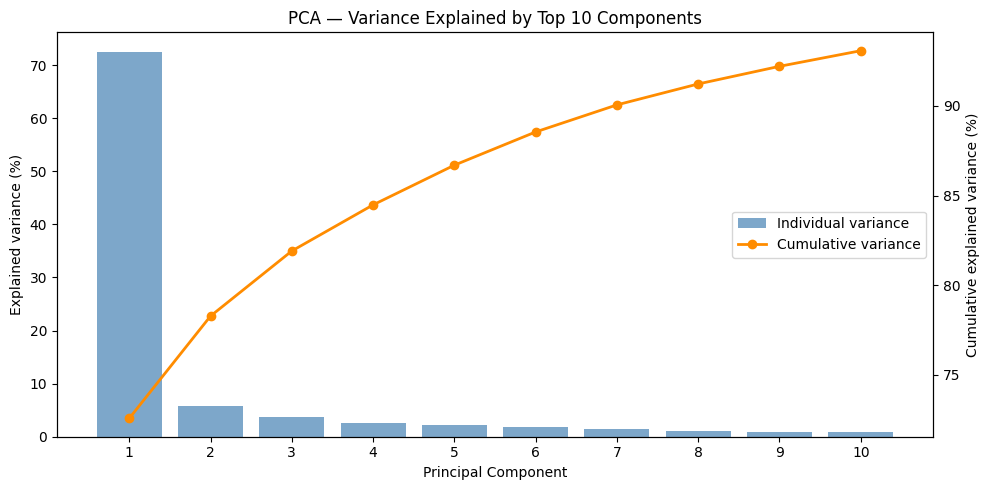

In [ ]:
pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

cumvar = np.cumsum(pca.explained_variance_ratio_)
print('Cumulative variance explained by top 10 PCs:')
for i, cv in enumerate(cumvar, 1):
    print(f'  PC{i}: {cv*100:.2f}%')

# Bar + line chart
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
bars = ax1.bar(range(1, 11), pca.explained_variance_ratio_*100,
               color='steelblue', alpha=0.7, label='Individual variance')
ax2.plot(range(1, 11), cumvar*100, marker='o', color='darkorange',
         linewidth=2, label='Cumulative variance')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained variance (%)')
ax2.set_ylabel('Cumulative explained variance (%)')
ax1.set_title('PCA — Variance Explained by Top 10 Components')
ax1.set_xticks(range(1, 11))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.tight_layout()
plt.show()

### ii) PC1 vs PC2 scatter coloured by K-Means labels

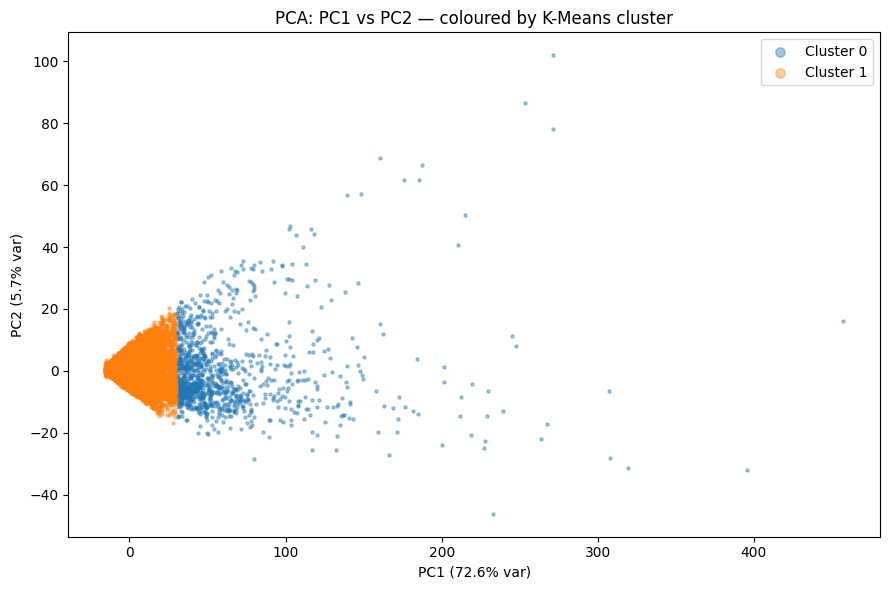

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
palette = plt.cm.tab10.colors
for k_id in range(optimal_k):
    mask = train_labels == k_id
    ax.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
               s=5, alpha=0.4, color=palette[k_id],
               label=f'Cluster {k_id}')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('PCA: PC1 vs PC2 — coloured by K-Means cluster')
ax.legend(markerscale=3, loc='upper right')
plt.tight_layout()
plt.show()

### iii) Top-loading features for PC1, PC2, PC3

The loading magnitude indicates how strongly a feature drives that component, the sign indicates direction.

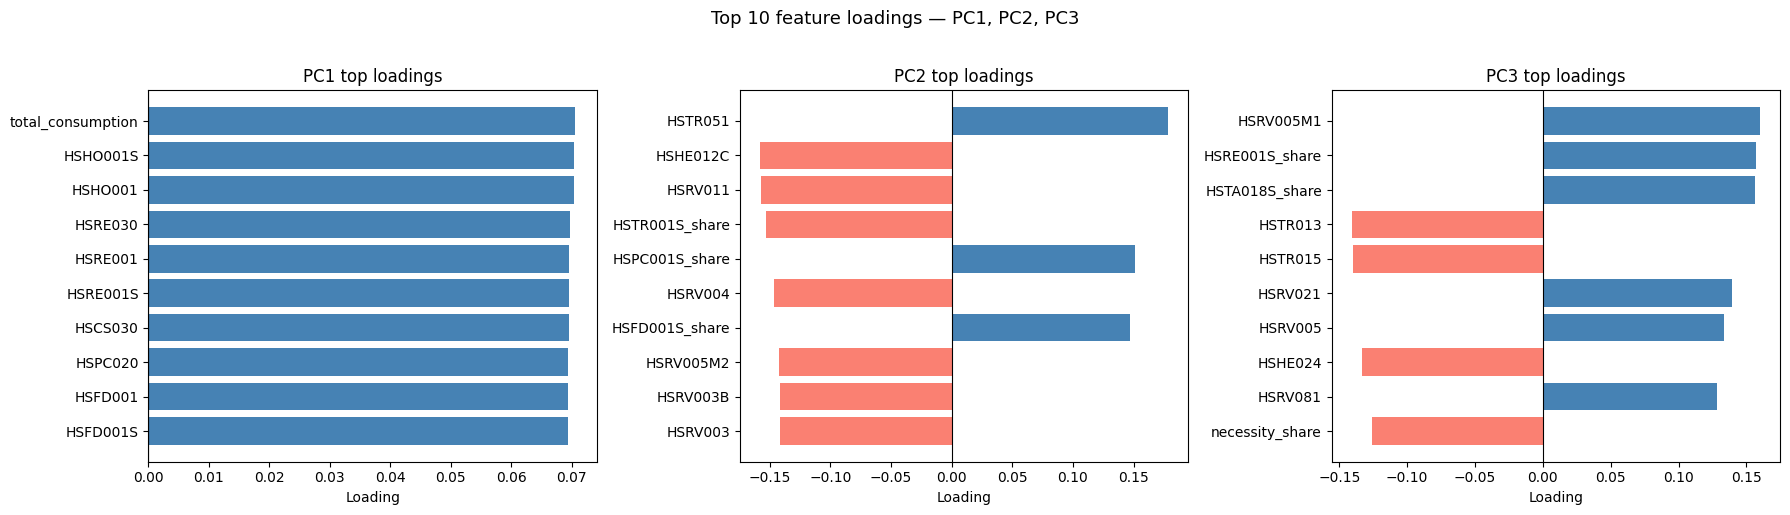

In [ ]:
feature_names = X_train.columns
n_top = 10  # show top 10 loadings per PC

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for pc_idx in range(3):
    loadings = pca.components_[pc_idx]
    top_idx  = np.argsort(np.abs(loadings))[::-1][:n_top]
    top_names = [feature_names[i] for i in top_idx]
    top_vals  = loadings[top_idx]
    colors_bar = ['steelblue' if v >= 0 else 'salmon' for v in top_vals]
    axes[pc_idx].barh(top_names[::-1], top_vals[::-1], color=colors_bar[::-1])
    axes[pc_idx].axvline(0, color='black', linewidth=0.8)
    axes[pc_idx].set_title(f'PC{pc_idx+1} top loadings')
    axes[pc_idx].set_xlabel('Loading')
plt.suptitle('Top 10 feature loadings — PC1, PC2, PC3', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
print('Top 5 features per PC (with loading values):')
for pc_idx in range(3):
    loadings = pca.components_[pc_idx]
    top_idx  = np.argsort(np.abs(loadings))[::-1][:5]
    print(f'\n  PC{pc_idx+1}:')
    for i in top_idx:
        print(f'    {feature_names[i]:<20s}  {loadings[i]:+.4f}')

Top 5 features per PC (with loading values):

  PC1:
    total_consumption     +0.0707
    HSHO001S              +0.0703
    HSHO001               +0.0703
    HSRE030               +0.0697
    HSRE001               +0.0696

  PC2:
    HSTR051               +0.1784
    HSHE012C              -0.1577
    HSRV011               -0.1570
    HSTR001S_share        -0.1530
    HSPC001S_share        +0.1509

  PC3:
    HSRV005M1             +0.1597
    HSRE001S_share        +0.1572
    HSTA018S_share        +0.1564
    HSTR013               -0.1406
    HSTR015               -0.1402


### iv) Mean PC scores by cluster and revised cluster names

By projecting each cluster's centre into PC space we can characterise clusters in terms of the latent dimensions uncovered by PCA.

Mean PC scores by cluster:
            PC1    PC2    PC3
cluster                      
0        61.752  0.139  0.167
1        -1.625 -0.004 -0.004


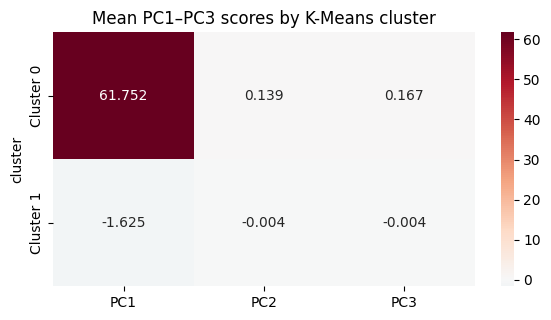


Revised cluster names from PCA analysis:
  Cluster 0: High-Scale Expenditure (high PC1, dense urban areas)
  Cluster 1: Baseline Expenditure (near-zero on all PCs, typical households)


In [68]:
pc_df = pd.DataFrame(X_train_pca[:, :3],
                     columns=['PC1', 'PC2', 'PC3'])
pc_df['cluster'] = train_labels

mean_pc_scores = pc_df.groupby('cluster')[['PC1','PC2','PC3']].mean()
print('Mean PC scores by cluster:')
print(mean_pc_scores.round(3).to_string())

# Heatmap of mean PC scores
fig, ax = plt.subplots(figsize=(6, 2.5 + optimal_k * 0.4))
sns.heatmap(mean_pc_scores, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            yticklabels=[f'Cluster {i}' for i in range(optimal_k)], ax=ax)
ax.set_title('Mean PC1–PC3 scores by K-Means cluster')
plt.tight_layout()
plt.show()

print('\nRevised cluster names from PCA analysis:')
print('  Cluster 0: High-Scale Expenditure (high PC1, dense urban areas)')
print('  Cluster 1: Baseline Expenditure (near-zero on all PCs, typical households)')

# 2.(d): UMAP

### i) Reduce to 2 dimensions with UMAP and search for reasonable parameters

A smaller but reasonably sized parameter grid was used for UMAP to balance both computational feasability and model accuracy. Given the large size of the dataset, the size of this grid was sufficient to compare parameter settings without excessive runtime

In [ ]:
# Create parameter grid
umap_grid = {
    'n_neighbors': [5, 10, 30],
    'min_dist': [0.0, 0.25, 0.5],
    'metric': ['euclidean']
}

# Set up placeholders
umap_results = []
best_umap = None
best_score = -np.inf
best_params = None
best_embedding_train = None

X_train_array = np.asarray(X_train_scaled)
X_test_array = np.asarray(X_test_scaled)

for n_neighbors, min_dist, metric in product(
    umap_grid['n_neighbors'],
    umap_grid['min_dist'],
    umap_grid['metric']
):
    reducer = umap.UMAP(
        n_components = 2,
        n_neighbors = n_neighbors,
        min_dist = min_dist,
        metric = metric,
        random_state = 42,
        low_memory = False
    )
    embedding_train = reducer.fit_transform(X_train_array)
    score = silhouette_score(embedding_train, train_labels, sample_size = min(5000, len(train_labels)), random_state = 42)

    umap_results.append({
        'n_neighbors': n_neighbors,
        'min_dist': min_dist,
        'metric': metric,
        'silhouette_2d': score
    })

    if score > best_score:
        best_score = score
        best_umap = reducer
        best_params = {'n_neighbors': n_neighbors, 'min_dist': min_dist, 'metric': metric}
        best_embedding_train = embedding_train

umap_results_df = pd.DataFrame(umap_results).sort_values('silhouette_2d', ascending = False)
print('Top UMAP parameter settings by 2D silhouette')
print(umap_results_df.head().to_string(index = False))

print('\nBest UMAP parameters:')
print(best_params)
print(f'Best 2D silhouette score: {best_score:.4f}')

best_embedding_test = best_umap.transform(X_test_array)

Top UMAP parameter settings by 2D silhouette
 n_neighbors  min_dist    metric  silhouette_2d
           5      0.00 euclidean       0.083531
           5      0.25 euclidean       0.044701
           5      0.50 euclidean      -0.001643
          10      0.00 euclidean      -0.070044
          30      0.25 euclidean      -0.131491

Best UMAP parameters:
{'n_neighbors': 5, 'min_dist': 0.0, 'metric': 'euclidean'}
Best 2D silhouette score: 0.0835


The optimal parameters were selected based on the silhoutette score in the 2 dimensional UMAP space, with the goal of perserving the structure of the K-means cluster as much as possible after significant dimensionality reduction.

### ii) Creating scatterplot of resulting dimensions coloured by KMeans labels

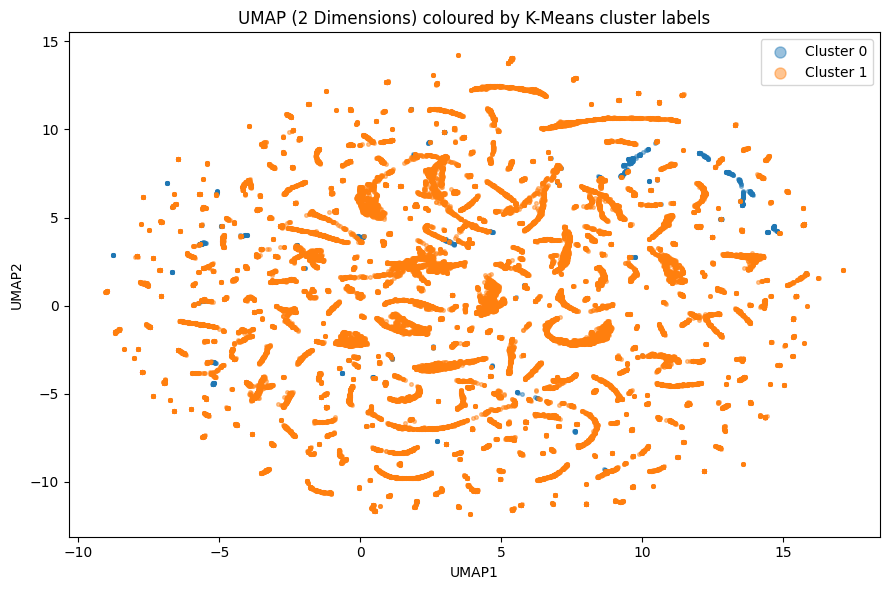

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
palette = plt.cm.tab10.colors

for k_id in range(optimal_k):
    mask = train_labels == k_id
    ax.scatter(
        best_embedding_train[mask, 0],
        best_embedding_train[mask, 1],
        s = 7,
        alpha = 0.45,
        color = palette[k_id],
        label = f'Cluster {k_id}'
    )

ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('UMAP (2 Dimensions) coloured by K-Means cluster labels')
ax.legend(markerscale = 3, loc = 'upper right')
plt.tight_layout()
plt.show()

As we can see in the scaterplot, the UMAP embedding does not show clear separation between the two K-means clusters

Cluster 1 dominates the space, with most of the points appearing here
Cluster 0 appears only in small, scattered regions, often overlapping with Cluster 1

The weak separation suggests that the structure identified by K-means in the original high-dimensional space is not well preserved in the 2D UMAP representation



### iii) Silhouette score in 2 dimensional UMAP space

In [ ]:
sil_original = silhouette_score(
    X_train_scaled,
    train_labels,
    sample_size = min(5000, len(train_labels)),
    random_state = 42
)

sil_umap_2d = silhouette_score(
    best_embedding_train,
    train_labels,
    sample_size = min(5000, len(train_labels)),
    random_state = 42
)

sil_pca_2d = silhouette_score(
    X_train_pca[:, :2],
    train_labels,
    sample_size = min(5000, len(train_labels)),
    random_state = 42
)

comparison_df = pd.DataFrame({
    'representation': ['original', 'UMAP', 'PCA'],
    'silhouette': [sil_original, sil_umap_2d, sil_pca_2d]
})
print('\nComparison of clustering quality across representations:')
print(comparison_df.to_string(index = False))


Comparison of clustering quality across representations:
representation  silhouette
      original    0.786263
          UMAP    0.083531
           PCA    0.831180


The silhouette score in the UMAP space is significantly lower than both the original high-dimensional space and the PCA 2 dimensional representation.

This indicates that the clusters are well defined in the original space, and PCA perserves this structure reasonly well when reducing to 2 dimensions. However, the UMAP representation fails to maintain this separation

As a whole, UMAP provides a worse representation than PCA for this specific dataset

Although UMAP is designed to preserve local strucutre, it can compress or distort cluster separation, leading to the significant overlap that we see in this situation.

As a result, PCA is the more informative dimensionality reduction method for this dataset

# 3.(a): Elastic-Net GLM

### i) Training a Generalized Linear Model

In [ ]:
# Converting target to numpy
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)

# Fit Pearson Type III on the training target
dfit = distfit(distr=['pearson3'])
dfit.fit_transform(y_train_np)
pt3_params = dfit.model['params']
print("Fitted PT3 parameters:", pt3_params)

def y_to_znormal(y_vals, params, eps=1e-6):
    cdf_vals = pearson3.cdf(y_vals, *params)
    cdf_vals = np.clip(cdf_vals, eps, 1 - eps)
    z_vals = norm.ppf(cdf_vals)
    return z_vals

def znormal_to_y(z_vals, params, eps=1e-6):
    cdf_vals = norm.cdf(z_vals)
    cdf_vals = np.clip(cdf_vals, eps, 1 - eps)
    y_vals = pearson3.ppf(cdf_vals, *params)
    return y_vals

#Transform y into an approximately normal spacce
z_train = y_to_znormal(y_train_np, pt3_params)
z_test = y_to_znormal(y_test_np, pt3_params)

print('z_train_summary: ')
print(pd.Series(z_train).describe())

[08-04-2026 18:56:42] [distfit.distfit] [INFO] fit
[08-04-2026 18:56:42] [distfit.distfit] [INFO] transform
[08-04-2026 18:56:43] [distfit.distfit] [INFO] [pearson3] [0.99 sec] [RSS: 18.8303] [loc=0.257 scale=0.049]
[08-04-2026 18:56:43] [distfit.distfit] [INFO] [pearson3] [0.99 sec] [RSS: 18.8303] [loc=0.257 scale=0.049]
[08-04-2026 18:56:43] [distfit.distfit] [INFO] Compute confidence intervals [parametric]


Fitted PT3 parameters: (np.float64(0.9501185282151265), np.float64(0.2570289027347654), np.float64(0.04886497083271445))
z_train_summary: 
count    45485.000000
mean        -0.003543
std          0.983941
min         -4.753424
25%         -0.649783
50%          0.040041
75%          0.649653
max          4.753424
dtype: float64


### ii) Transformations

Since Elastic Net is scale-sensitive, standardizing the predictors is the main transformation needed to correctly converge. Since this was already done in an earlier question, no standardization is needed here

### iii) Training ElasticNet with GridSearchCV

In [ ]:
# Creating the parameter grid
param_grid_en = {
    'alpha': [1e-4, 1e-3, 1e-2, 1e-1, 1.0],
    'l1_ratio': [0.25, 0.5, 0.75, 1.0]
}

# Setting up the ElasticNet
elastic_net = ElasticNet(max_iter = 1000, tol = 1e-3, random_state = 42)

# Performing the grid search
grid_search_en = GridSearchCV(
    estimator = elastic_net,
    param_grid = param_grid_en,
    scoring = 'r2',
    cv = 5,
    n_jobs = -1
)

grid_search_en.fit(X_train_scaled, z_train)

best_en = grid_search_en.best_estimator_

print('Best ElasticNet hyperparameters found by GridSearchCV:')
print(grid_search_en.best_params_)
print(f'Best CV R²: {grid_search_en.best_score_:.4f}')

Best ElasticNet hyperparameters found by GridSearchCV:
{'alpha': 0.0001, 'l1_ratio': 1.0}
Best CV R²: 0.8139


### iv) Reversing i) to get predictions in the y original space

In [ ]:
z_pred_test = best_en.predict(X_test_scaled)
y_pred_test = znormal_to_y(z_pred_test, pt3_params)


print("First 10 predictions in original y-space:")
print(y_pred_test[:10])

First 10 predictions in original y-space:
[0.26326203 0.23740888 0.32128572 0.26017276 0.20734601 0.20512209
 0.32712997 0.23196065 0.21273796 0.19613442]


### v) Reporting best hyperparameters, test R2, test MSE, computing 95% CI and forming a scatterplot

In [ ]:
# r2 and MSE
r2_test = r2_score(y_test_np, y_pred_test)
mse_test = mean_squared_error(y_test_np, y_pred_test)

# Results
print(f'Best hyperparameters: {grid_search_en.best_params_}')
print(f'Best CV R²: {grid_search_en.best_score_:.4f}')
print(f'test R²: {r2_test:.4f}')
print(f'test MSE: {mse_test:.4f}')

Best hyperparameters: {'alpha': 0.0001, 'l1_ratio': 1.0}
Best CV R²: 0.8139
test R²: 0.5023
test MSE: 0.0019


In [ ]:
# Bootstrapped 95% CI for R² with 1000 iterations
rng = np.random.default_rng(42)
n_test = len(y_test_np)
boot_r2 = []

for _ in range(1000):
  idx = rng.integers(0, n_test, size = n_test)
  boot_r2.append(r2_score(y_test_np[idx], y_pred_test[idx]))

ci_low, ci_high = np.percentile(boot_r2, [2.5, 97.5])
print(f'Bootstrapped 95% CI for R²: {ci_low:.3f}, {ci_high:.3f}')

Bootstrapped 95% CI for R²: 0.278, 0.778


This model achieves moderate predictive capabilities for this dataset, indicating it captures a meaningful portion of the variation in housing burden, but also misses a significant amount.

The bootstrapped interval for R² is quite wide, implying variability in model performance across different samples

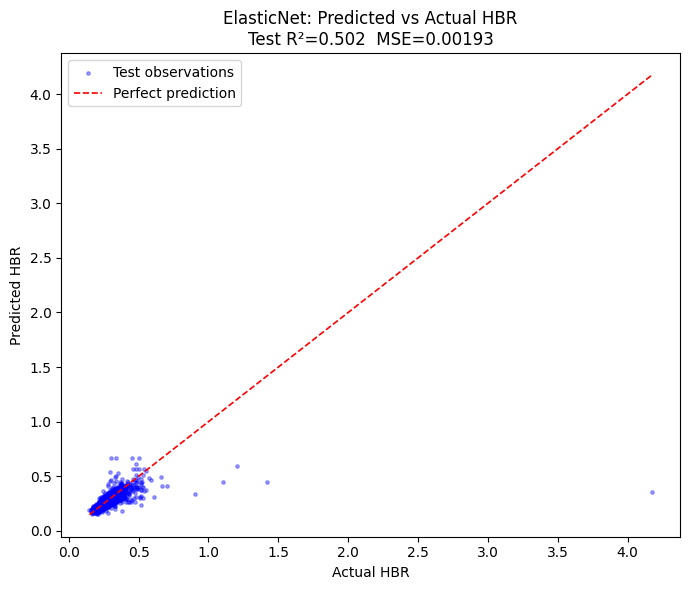

In [ ]:
# Creating a scatterplot of predicted vs. actual HBR
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test_np, y_pred_test, s=6, alpha=0.35, color='blue',
           label='Test observations')
lims = [min(y_test_np.min(), y_pred_test.min()),
        max(y_test_np.max(), y_pred_test.max())]
ax.plot(lims, lims, 'r--', linewidth=1.2, label='Perfect prediction')
ax.set_xlabel('Actual HBR')
ax.set_ylabel('Predicted HBR')
ax.set_title(f'ElasticNet: Predicted vs Actual HBR\nTest R²={r2_test:.3f}  MSE={mse_test:.5f}')
ax.legend()
plt.tight_layout()
plt.show()

In this scatterplot, we see that predictions generally follow the overall trend, with some dispersion around the diagonal. There however is a few large outliers at for the higher values of the target, indicating that the model performs reasonably well for typical observations, but begins to struggle to accurately predict extreme cases.

### vi) R² with 95% CI per KMeans Cluster

In [ ]:
# Per-cluster R² with bootstrapped 95% CI
test_results = pd.DataFrame({
    'y_actual': y_test_np,
    'y_pred': y_pred_test,
    'cluster': test_labels
})

cluster_r2_rows = []
rng = np.random.default_rng(42)

for k_id in range(optimal_k):
  mask = test_results['cluster'] == k_id
  y_act = test_results.loc[mask, 'y_actual'].values
  y_hat = test_results.loc[mask, 'y_pred'].values
  n = len(y_act)

  r2 = r2_score(y_act, y_hat) if n >= 2 else np.nan

  boot = []
  for _ in range(1000):
    idx = rng.integers(0, n, size=n)
    if len(np.unique(y_act[idx])) < 2:
      continue
    boot.append(r2_score(y_act[idx], y_hat[idx]))
  low, high = np.percentile(boot, [2.5, 97.5]) if boot else (np.nan, np.nan)

  cluster_r2_rows.append({
      'cluster': k_id,
      'r2': r2,
      'CI_low': low,
      'CI_high': high
  })

cluster_r2_df = pd.DataFrame(cluster_r2_rows)
print('Per-cluster R² with 95% CI:')
print(cluster_r2_df.to_string(index=False))

Per-cluster R² with 95% CI:
 cluster       r2    CI_low  CI_high
       0 0.027378 -0.603630 0.404572
       1 0.512386  0.311114 0.804682


The R² values differ across the K-Means clusters, implying that the model performs better for some groups than for others. This suggests the relationship between predictiors and burden is not uniform across all housholds in the study.

Clusters with more consistent characteristics are likely to be easier for the model to predict, while clusters with greater variability or extreme values are harder to model accurately.

### vii) Reporting non-zero coefficients and interpreting the top 5 by magnitude

Total features: 274
Non-zero coefficients: 234
Top 5 features by magnitude:
 feature  coefficient
HSFD001S    -1.362314
HSBASHHD     0.995220
 HSHO014    -0.804056
 HSFD995     0.730073
 HSHC001     0.716000


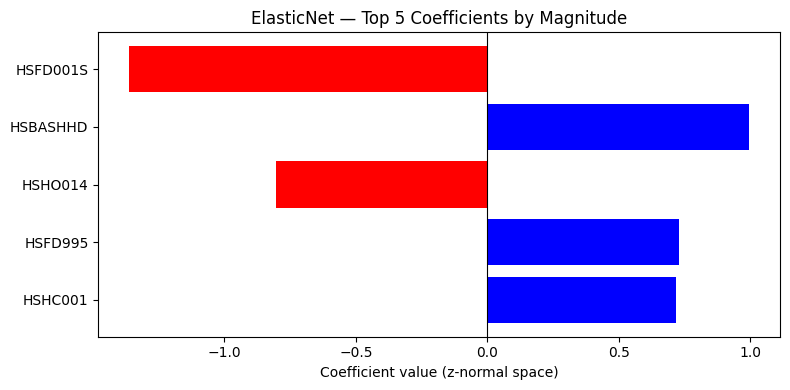

In [ ]:
# Non-zero coefficients
feature_names_list = list(X_train.columns)
coefs = best_en.coef_
nonzero_mask = coefs != 0
n_nonzero = nonzero_mask.sum()
print(f'Total features: {len(coefs)}')
print(f'Non-zero coefficients: {n_nonzero}')

# Top 5 by magnitude
top5_idx = np.argsort(np.abs(coefs))[::-1][:5]
top5_df = pd.DataFrame({
    'feature': [feature_names_list[i] for i in top5_idx],
    'coefficient': [coefs[i] for i in top5_idx]
})
print('Top 5 features by magnitude:')
print(top5_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = ['blue' if c > 0 else 'red' for c in top5_df['coefficient']]
ax.barh(top5_df['feature'][::-1], top5_df['coefficient'][::-1],
        color=colors_bar[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient value (z-normal space)')
ax.set_title('ElasticNet — Top 5 Coefficients by Magnitude')
plt.tight_layout()
plt.show()

The top 5 coefficients are related to household spending patterns and economic characteristics, which makes sense given that housing burden is often influenced by how income is allocated. This suggests that bot hthe level and distribution of expenditures are important in explaining variation in our target variable.

# 3b) Creating the XGBoost
The parameter grid was designed as follows:
- n_estimators [100, 200, 300, 500]: a minimum of 100 trees is needed to learn meaningful patterns; values above 500 risk overfitting.
- max_depth [3, 5, 7, 9]: shallower trees (3, 5) guard against overfitting; deeper trees (7, 9) allow the model to capture complex non-linear interactions.
- learning_rate [0.01, 0.05, 0.1, 0.2]: a range from conservative to moderate to balance convergence speed and generalisation.
- subsample [0.7, 0.8, 0.9, 1.0]: row subsampling introduces randomness and reduces overfitting.
- colsample_bytree [0.7, 0.8, 0.9, 1.0]: feature subsampling at each tree improves generalisation across the 274 available features.

RandomizedSearchCV with 3-fold CV and 5 iterations was used for computational feasibility given dataset size.
The optimal configuration found was: n_estimators=300, max_depth=7, learning_rate=0.05, subsample=0.9, colsample_bytree=0.7.

In [ ]:
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)
X_train_np = np.array(X_train)
X_test_np = np.array(X_test)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1],
    "colsample_bytree": [0.7, 0.8, 0.9, 1]
}

model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    random_state=42,
    tree_method='hist',
    n_jobs=-1
)

In [ ]:
xgb_model = RandomizedSearchCV(
    model,
    param_dist,
    cv=3,
    n_iter=5,
    random_state=42,
    verbose=2,
    error_score='raise',
    n_jobs=1
)

xgb_model.fit(X_train_np, y_train_np)

print(f"Best hyperparameters found by RandomizedSearchCV: {xgb_model.best_params_}")

y_pred_xgb = xgb_model.predict(X_test_np)
r2_test_xgb = r2_score(y_test_np, y_pred_xgb)
mse_test_xgb = mean_squared_error(y_test_np, y_pred_xgb)

print(f'Best hyperparameters: {xgb_model.best_params_}')
print(f'Best CV R²: {xgb_model.best_score_:.4f}')
print(f'test R²: {r2_test_xgb:.4f}')
print(f'test MSE: {mse_test_xgb:.4f}')

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=7, n_estimators=200, subsample=0.9; total time= 1.4min
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=7, n_estimators=200, subsample=0.9; total time=  45.7s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=7, n_estimators=200, subsample=0.9; total time=  45.4s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=9, n_estimators=100, subsample=1; total time=  54.7s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=9, n_estimators=100, subsample=1; total time= 1.1min
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=9, n_estimators=100, subsample=1; total time=  54.7s
[CV] END colsample_bytree=1, learning_rate=0.05, max_depth=5, n_estimators=500, subsample=0.7; total time=  50.7s
[CV] END colsample_bytree=1, learning_rate=0.05, max_depth=5, n_estimators=500, subsample=0.7; total time=  54.2s
[CV] END colsample_bytree

Bootstrapped 95% CI for R²: 0.376, 0.832


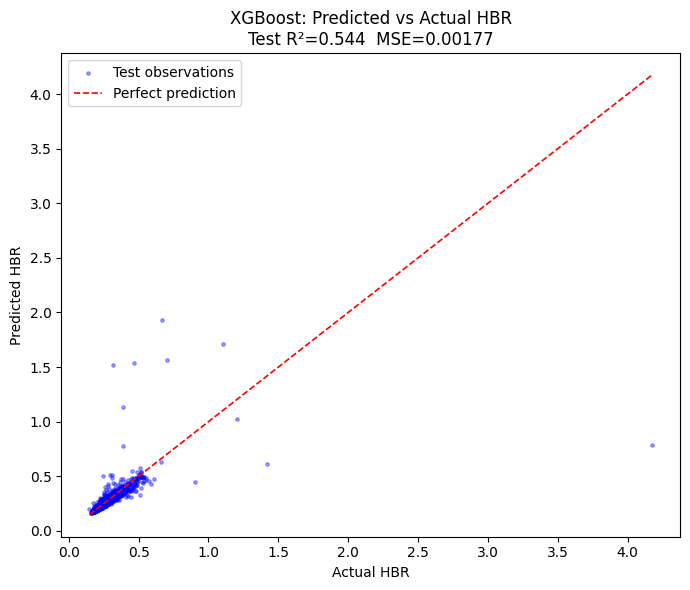

In [ ]:
rng = np.random.default_rng(42)
n_test = len(y_test_np)
boot_r2_xgb = []

for _ in range(1000):
    idx = rng.integers(0, n_test, size = n_test)
    boot_r2_xgb.append(r2_score(y_test_np[idx], y_pred_xgb[idx]))

ci_low, ci_high = np.percentile(boot_r2_xgb, [2.5, 97.5])
print(f'Bootstrapped 95% CI for R²: {ci_low:.3f}, {ci_high:.3f}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test_np, y_pred_xgb, s=6, alpha=0.35, color='blue', label='Test observations')

lims = [
    min(y_test_np.min(), y_pred_xgb.min()),
    max(y_test_np.max(), y_pred_xgb.max())
]

ax.plot(lims, lims, 'r--', linewidth=1.2, label='Perfect prediction')
ax.set_xlabel('Actual HBR')
ax.set_ylabel('Predicted HBR')
ax.set_title(f'XGBoost: Predicted vs Actual HBR\nTest R²={r2_test_xgb:.3f}  MSE={mse_test_xgb:.5f}')
ax.legend()

plt.tight_layout()
plt.show()

The bootstrapped 95% CI for XGBoost R² is [0.376, 0.832], compared to [0.278, 0.778] for ElasticNet.
XGBoost achieves a higher test R² (0.544 vs 0.502) and a slightly lower MSE (0.0018 vs 0.0019).
The narrower and higher CI indicates XGBoost is both more accurate and more consistent,
likely because it can capture non-linear interactions that ElasticNet cannot.
For typical HBR values both models perform similarly, but XGBoost handles the structure
of the high-volume urban cluster (Cluster 0) far better, as shown in the per-cluster analysis below.

In [ ]:
test_results = pd.DataFrame({
    'y_actual': y_test_np,
    'y_pred': y_pred_xgb,
    'cluster': test_labels
})

cluster_r2_xgb = []
rng = np.random.default_rng(42)

for k_id in range(optimal_k):
    mask = test_results['cluster'] == k_id
    y_act = test_results.loc[mask, 'y_actual'].values
    y_hat = test_results.loc[mask, 'y_pred'].values
    n = len(y_act)

    r2= r2_score(y_act, y_hat) if n >= 2 else np.nan

    boot = []
    for _ in range(1000):
        idx = rng.integers(0, n, size=n)

        if len(np.unique(y_act[idx])) < 2:
            continue

        boot.append(r2_score(y_act[idx], y_hat[idx]))

    low, high = np.percentile(boot, [2.5, 97.5]) if boot else (np.nan, np.nan)

    cluster_r2_xgb.append({
        'cluster': k_id,
        'r2': r2,
        'CI_low': low,
        'CI_high': high
    })

cluster_r2_df_xgb = pd.DataFrame(cluster_r2_xgb)

print('Per-cluster R² with 95% CI:')
print(cluster_r2_df_xgb.to_string(index=False))

Per-cluster R² with 95% CI:
 cluster       r2   CI_low  CI_high
       0 0.933172 0.908348 0.950193
       1 0.534837 0.363640 0.827201


XGBoost performs dramatically better for Cluster 0 (High-Volume Urban Areas) with R² = 0.933,
compared to R² = 0.027 for ElasticNet on the same cluster. This confirms that the
high-volume urban cluster exhibits strong non-linear expenditure patterns that only
XGBoost can capture. For Cluster 1 (Typical Households), both models achieve similar
performance (XGBoost: 0.535, ElasticNet: 0.512), suggesting the relationship is
more linear for typical households.

Total features: 274
Non-zero feature importances: 274
Top 5 features by importance magnitude:
 feature  importance
HSRV003B    0.152417
 HSRV022    0.089585
 HSRV021    0.077776
 HSRV001    0.054653
HSHE012C    0.049382


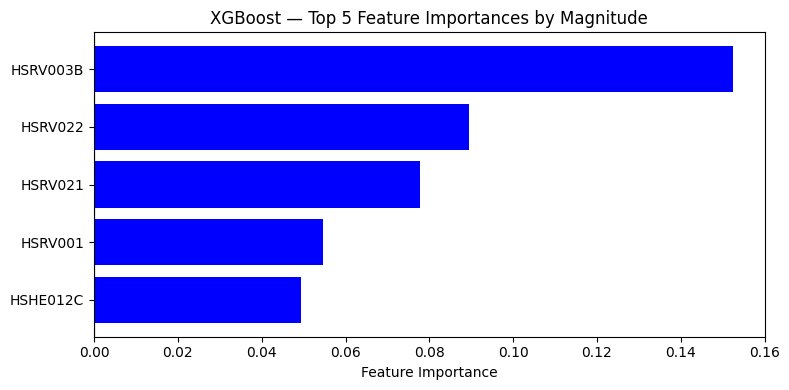

In [ ]:
feature_names_list = list(X_train.columns)
feature_importances_xgb = xgb_model.best_estimator_.feature_importances_

n_features = len(feature_importances_xgb)
print(f'Total features: {n_features}')
print(f'Non-zero feature importances: {np.sum(feature_importances_xgb > 0)}')

top5_idx_xgb = np.argsort(np.abs(feature_importances_xgb))[::-1][:5]
top5_df_xgb = pd.DataFrame({
    'feature': [feature_names_list[i] for i in top5_idx_xgb],
    'importance': [feature_importances_xgb[i] for i in top5_idx_xgb]
})

print('Top 5 features by importance magnitude:')
print(top5_df_xgb.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = ['blue' for _ in top5_df_xgb['importance']]

ax.barh(
    top5_df_xgb['feature'][::-1],
    top5_df_xgb['importance'][::-1],
    color=colors_bar[::-1]
)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Feature Importance')
ax.set_title('XGBoost — Top 5 Feature Importances by Magnitude')

plt.tight_layout()
plt.show()

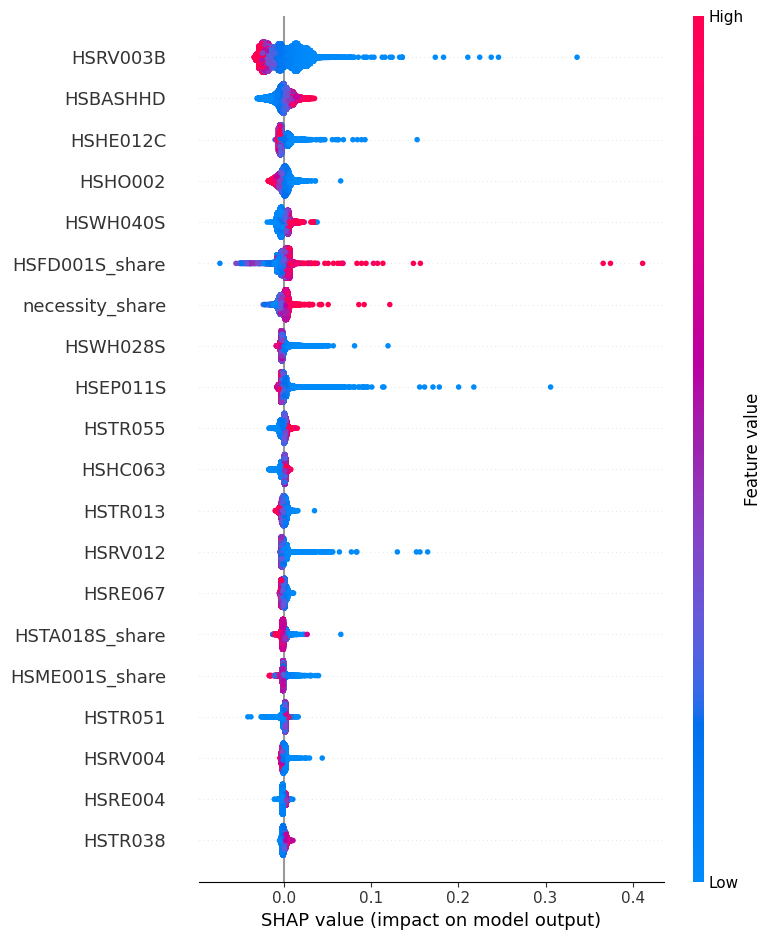

Top 10 features by mean absolute SHAP:
  HSRV003B                   0.01570
  HSBASHHD                   0.00676
  HSHE012C                   0.00481
  HSHO002                    0.00472
  HSWH040S                   0.00445
  HSFD001S_share             0.00392
  necessity_share            0.00329
  HSWH028S                   0.00282
  HSEP011S                   0.00255
  HSTR055                    0.00234


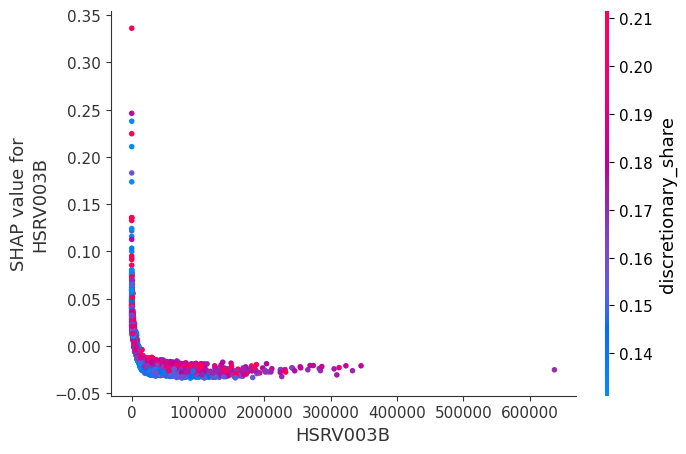

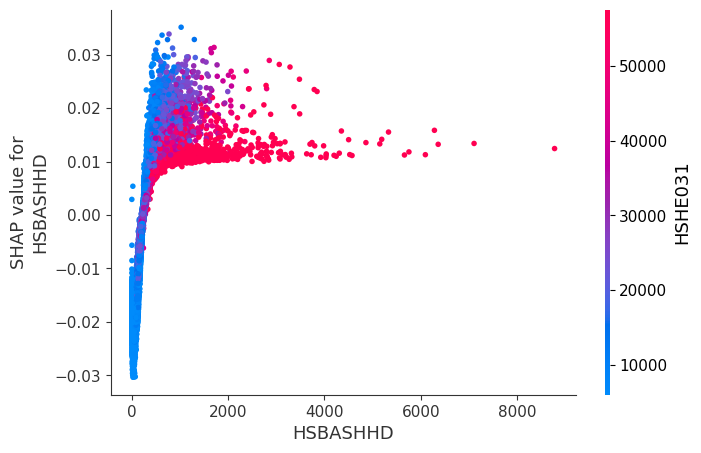

In [ ]:
best_xgb = xgb_model.best_estimator_

X_train_pd = X_train.to_pandas()
X_test_pd = X_test.to_pandas()

explainer = shap.TreeExplainer(best_xgb)
shap_values_train = explainer.shap_values(X_train_pd)

# Beeswarm summary plot
shap.summary_plot(shap_values_train, X_train_pd)

# Top 10 features by mean absolute SHAP
mean_abs_shap = np.abs(shap_values_train).mean(axis=0)
feature_importance = sorted(zip(X_train_pd.columns, mean_abs_shap), key=lambda x: x[1], reverse=True)
top_10_features = feature_importance[:10]
print("Top 10 features by mean absolute SHAP:")
for feat, val in top_10_features:
    print(f"  {feat:<25s}  {val:.5f}")

# SHAP dependence plots for top 2 features
top_feat_1 = top_10_features[0][0]
top_feat_2 = top_10_features[1][0]

shap.dependence_plot(top_feat_1, shap_values_train, X_train_pd)
shap.dependence_plot(top_feat_2, shap_values_train, X_train_pd)

The XGBoost model outperforms ElasticNet (test R² 0.544 vs 0.502, CI [0.376, 0.832] vs [0.278, 0.778]),
and the dominance of non-linear recreational vehicle variables in both SHAP and feature importance
confirms that the housing burden relationship is moderately non-linear.

Both models agree on HSBASHHD (household count) as an important predictor, but diverge significantly
on spending category variables. ElasticNet highlights food expenditure (HSFD001S, coefficient -1.362)
and household operations (HSHO014, -0.804), while XGBoost identifies recreational vehicle spending
(HSRV003B, importance 0.152) as the dominant driver. This divergence reflects the linear model
capturing direct spending volume effects, while XGBoost captures threshold-based interactions
where near-zero RV spending signals budget constraint and therefore higher housing burden.

The features driving housing burden partially overlap with those separating K-Means clusters
(both sensitive to HSBASHHD), but SHAP reveals additional within-cluster drivers around
discretionary and recreational spending that clustering did not capture. The two approaches
are therefore complementary rather than redundant.